<a href="https://colab.research.google.com/github/dahassanm-jpg/arabic-morph-aware-bpe-nlp/blob/main/NLP_Project_Dalya_222053121_Arabic_Morph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems

**Student:** Dalya Hassan  
**Student ID:** 222053121  
**Course:** Natural Language Processing (Graduate Course)  
**Instructor:** Prof. Aiman Ahmed Abusamra  
**Program:** Master of Computer Engineering  
**Institution:** Islamic University of Gaza  
**Date:** June 2026

This notebook implements a focused comparison between **standard BPE** and **CAMeL-based morphology-aware BPE** for Arabic NLP. It evaluates intrinsic tokenization behavior, text classification, and candidate-pool retrieval, then reports statistical significance and error analysis.

**Final experiment design:** both tokenizers use the same Arabic normalization; the morphology-aware condition differs by applying CAMeL morphological segmentation before BPE training. Strict mode aborts the run if CAMeL is unavailable.


## 0. Workspace setup + notebook-level imports

This single cell owns every Python import the notebook uses at the top
level, plus an idempotent workspace cleanup and directory creation. All
downstream cells assume these names are in scope — they do not re-import.

Safe to re-run at any point: cleanup is idempotent and creates output
directories afresh.


In [1]:
import os
import sys
import glob
import shutil
import importlib
import subprocess
from pathlib import Path
from IPython.display import Image, Markdown, display

for _dir in ("src", "results", "trained_tokenizers", "__pycache__"):
    shutil.rmtree(_dir, ignore_errors=True)

for _f in (
    "config.py",
    "check_segmentation.py",
    "run_analysis.py",
    "run_bpe_tasks.py",
    "run_vocab_sensitivity.py",
    "compile_results.py",
):
    if os.path.exists(_f):
        os.remove(_f)

for _dir in ("src", "results", "results/figures", "trained_tokenizers"):
    os.makedirs(_dir, exist_ok=True)

if "." not in sys.path:
    sys.path.insert(0, ".")

print(f"Python  : {sys.version_info.major}.{sys.version_info.minor}."
      f"{sys.version_info.micro}")
print(f"Cwd     : {Path.cwd()}")
print(f"Cleaned : src/, results/, trained_tokenizers/, __pycache__/")
print("Setup OK. Proceed to Section 1.")


Python  : 3.12.13
Cwd     : /content
Cleaned : src/, results/, trained_tokenizers/, __pycache__/
Setup OK. Proceed to Section 1.


## 1. Install dependencies (~2-3 min)

In [2]:
!pip install -q datasets tokenizers scikit-learn numpy pandas scipy \
    rank-bm25 matplotlib tqdm camel-tools

!camel_data -i morphology-db-msa-r13
!camel_data -i disambig-mle-calima-msa-r13


No new packages will be installed.
No new packages will be installed.


## 2. Write the project files
Creates the folder layout and writes every module + script to disk.

In [3]:
%%writefile config.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Focused configuration for the BPE-core comparison.

Single steering switch: RUN_MODE = "quick" | "medium" | "full".
  - quick  : tiny smoke test (CPU, ~2 min).
  - medium : default — recommended final submission scale.
  - full   : larger samples and more seeds.

Override anything via env vars: RUN_MODE, MORPH_BACKEND, MAX_TRAIN_SAMPLES,
MAX_TEST_SAMPLES, MAX_RETRIEVAL_QUERIES, BPE_VOCAB_SIZE.
"""
import os


def _env_int_or_none(name, current):
    raw = os.environ.get(name)
    if raw is None:
        return current
    raw = raw.strip().lower()
    if raw in ("none", "0", "all", ""):
        return None
    return int(raw)


RUN_MODE = os.environ.get("RUN_MODE", "medium").strip().lower()
if RUN_MODE not in ("quick", "medium", "full"):
    print(f"[config] Unknown RUN_MODE={RUN_MODE!r}; defaulting to 'medium'.")
    RUN_MODE = "medium"

PROJECT_ROOT = os.path.dirname(os.path.abspath(__file__))
DATA_DIR = os.path.join(PROJECT_ROOT, "data_cache")
RESULTS_DIR = os.path.join(PROJECT_ROOT, "results")
TOKENIZERS_DIR = os.path.join(PROJECT_ROOT, "trained_tokenizers")
for d in (DATA_DIR, RESULTS_DIR, TOKENIZERS_DIR):
    os.makedirs(d, exist_ok=True)

CLASSIFICATION_DATASET = "mohamedadaly/labr"
LABR_TASK = "polarity"

RETRIEVAL_DATASET = os.environ.get("RETRIEVAL_DATASET", "mteb/MIRACLReranking")
RETRIEVAL_LANG = "ar"
RETRIEVAL_SPLIT = "dev"

MORPH_BACKEND = os.environ.get("MORPH_BACKEND", "camel")
MORPH_MODE = "full"
REQUIRE_CAMEL = os.environ.get("REQUIRE_CAMEL", "1") == "1"

SEED = 42
SEED_TEST = 42                # FIXED test set across BPE seeds
BPE_SEEDS = [42, 123, 2024]

NDCG_K = 10
RECALL_K = 10
RETRIEVAL_TOP_K = [1, 5, 10]

BOOTSTRAP_ITERS = 1000
SIGNIFICANCE_ALPHA = 0.05

BPE_MIN_FREQUENCY = 2

VOCAB_SENSITIVITY_SIZES = [4000, 8000, 16000]
VOCAB_SENSITIVITY_SEED = 42
CLASSIFIER = "logistic_regression"
TFIDF_MAX_FEATURES = 50000
LOGREG_MAX_ITER = 2000

RETRIEVAL_MODE = "candidate_pool"
RETRIEVAL_MODEL = "BM25"
PRIMARY_RETRIEVAL_METRIC = "nDCG@10"
PRECISION_K = 10
HIT_K = 10


if RUN_MODE == "quick":
    MAX_TRAIN_SAMPLES = 300
    MAX_TEST_SAMPLES = 150
    MAX_RETRIEVAL_QUERIES = 40
    BPE_VOCAB_SIZE = 4000
    BPE_SEEDS = [42]
    BPE_TRAIN_SAMPLES = 1000   # unsupervised BPE corpus
    BOOTSTRAP_ITERS = 500
elif RUN_MODE == "medium":
    MAX_TRAIN_SAMPLES = 8000        # labeled examples for the classifier
    MAX_TEST_SAMPLES = 2000
    MAX_RETRIEVAL_QUERIES = 200     # ~100 eval queries after the train/eval split
    BPE_VOCAB_SIZE = 8000
    BPE_SEEDS = [42, 123, 2024, 7, 31]  # 5 seeds for tighter paired-t CIs
    BPE_TRAIN_SAMPLES = 12000       # BPE sees MORE text (unsupervised)
    BOOTSTRAP_ITERS = 3000          # safer-than-default bootstrap
else:  # full
    MAX_TRAIN_SAMPLES = None
    MAX_TEST_SAMPLES = None
    MAX_RETRIEVAL_QUERIES = 300
    BPE_VOCAB_SIZE = 16000
    BPE_SEEDS = [42, 123, 2024, 7, 31]
    BPE_TRAIN_SAMPLES = None        # use everything
    BOOTSTRAP_ITERS = 5000

MAX_TRAIN_SAMPLES = _env_int_or_none("MAX_TRAIN_SAMPLES", MAX_TRAIN_SAMPLES)
MAX_TEST_SAMPLES = _env_int_or_none("MAX_TEST_SAMPLES", MAX_TEST_SAMPLES)
MAX_RETRIEVAL_QUERIES = _env_int_or_none("MAX_RETRIEVAL_QUERIES", MAX_RETRIEVAL_QUERIES)
BPE_VOCAB_SIZE = _env_int_or_none("BPE_VOCAB_SIZE", BPE_VOCAB_SIZE)
BPE_TRAIN_SAMPLES = _env_int_or_none("BPE_TRAIN_SAMPLES", BPE_TRAIN_SAMPLES)

print(
    f"[config] RUN_MODE={RUN_MODE!r}  backend={MORPH_BACKEND}  "
    f"require_camel={REQUIRE_CAMEL}  "
    f"clf_train<={MAX_TRAIN_SAMPLES}  bpe_train<={BPE_TRAIN_SAMPLES}  "
    f"test<={MAX_TEST_SAMPLES}  bpe_seeds={BPE_SEEDS}  "
    f"retrieval_q<={MAX_RETRIEVAL_QUERIES}  bpe_vocab={BPE_VOCAB_SIZE}"
)


Writing config.py


In [4]:
%%writefile src/__init__.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Arabic Morphology-Aware Tokenization research package.
"""


Writing src/__init__.py


In [5]:
%%writefile src/morphology.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Arabic Morphological Segmentation
==================================

Implements two segmentation strategies:

1. Rule-based greedy longest-match segmenter (no external dependencies).
   Splits common Arabic proclitics (e.g. al-, wa-, fa-, bi-, li-) and
   enclitics (e.g. -ha, -hum, -kum, -ni) from word stems, plus some
   inflectional suffixes (e.g. -un, -in, -at, -an).

   referenced in the proposal.

Both segmenters return whitespace-separated morpheme strings, so they can
be plugged in as a preprocessing step before any subword tokenizer.
"""
from __future__ import annotations
import re
import unicodedata
from typing import List, Optional


PROCLITICS = [
    "وبال", "فبال", "وكال", "فكال",  # و/ف + بـ/كـ + ال
    "ولل", "فلل",                     # و/ف + لـ + ال
    "بال", "كال", "وال", "فال", "لل",
    "ال",
    "وب", "فب", "ول", "فل", "وس", "فس",
    "س", "ب", "ل", "و", "ف",
]

ENCLITICS = [
    "كما", "كمو", "هما", "هنا", "نا",
    "هم", "هن", "كم", "كن", "ها", "ني",
    "ه", "ك", "ي",
]

INFLECTIONAL_SUFFIXES = [
    "ون", "ين", "ات", "ان", "ية", "تي", "تك", "ته", "تها", "تهم",
]

MIN_STEM_LENGTH = 3  # never strip an affix if the remaining stem is shorter than this

_DIACRITICS = re.compile(r"[\u064B-\u065F\u0670\u0640]")  # fathatan..sukun, dagger alif, tatweel

def normalize_arabic(text: str) -> str:
    """Light-touch normalization that does NOT change orthographic identity.

    - Removes diacritics (tashkeel) and tatweel.
    - Unifies some characters that are visually/encoding ambiguous.
    - Collapses whitespace.
    """
    if not text:
        return ""
    text = unicodedata.normalize("NFKC", text)
    text = _DIACRITICS.sub("", text)
    text = text.replace("\u0622", "\u0627").replace("\u0623", "\u0627").replace("\u0625", "\u0627")
    text = text.replace("\u0649", "\u064A")
    text = re.sub(r"\s+", " ", text).strip()
    return text

class RuleBasedSegmenter:
    """Greedy longest-match Arabic morphological segmenter.

    For each whitespace token:
      1. Strip the longest matching proclitic from the left (if stem stays long enough).
      2. Strip the longest matching enclitic from the right.
      3. Optionally strip one inflectional suffix.

    The output is a single string with morpheme boundaries marked by spaces
    so downstream tokenizers (e.g. BPE) see each morpheme as its own word.

    The `mode` argument supports ablation studies:
      - "full"          : strip proclitics + enclitics + inflectional (default)
      - "prefixes"      : strip proclitics only
      - "suffixes"      : strip enclitics + inflectional only
      - "normalization" : normalize only, no segmentation
    """

    def __init__(
        self,
        proclitics: Optional[List[str]] = None,
        enclitics: Optional[List[str]] = None,
        inflectional: Optional[List[str]] = None,
        min_stem_length: int = MIN_STEM_LENGTH,
        split_inflectional: bool = True,
        mode: str = "full",
    ):
        self.proclitics = sorted(proclitics or PROCLITICS, key=len, reverse=True)
        self.enclitics = sorted(enclitics or ENCLITICS, key=len, reverse=True)
        self.inflectional = sorted(inflectional or INFLECTIONAL_SUFFIXES, key=len, reverse=True)
        self.min_stem_length = min_stem_length
        self.split_inflectional = split_inflectional
        if mode not in ("full", "prefixes", "suffixes", "normalization"):
            raise ValueError(f"Unknown ablation mode: {mode}")
        self.mode = mode

    def _is_arabic_word(self, word: str) -> bool:
        return bool(re.search(r"[\u0600-\u06FF]", word))

    def segment_word(self, word: str) -> List[str]:
        """Segment a single word into morpheme pieces, respecting the ablation mode."""
        if not word or not self._is_arabic_word(word):
            return [word] if word else []
        if self.mode == "normalization":
            return [word]

        pieces: List[str] = []
        stem = word
        strip_prefix = self.mode in ("full", "prefixes")
        strip_suffix = self.mode in ("full", "suffixes")

        if strip_prefix:
            for p in self.proclitics:
                if stem.startswith(p) and len(stem) - len(p) >= self.min_stem_length:
                    pieces.append(p)
                    stem = stem[len(p):]
                    break

        tail: List[str] = []
        if strip_suffix:
            for e in self.enclitics:
                if stem.endswith(e) and len(stem) - len(e) >= self.min_stem_length:
                    tail.insert(0, e)
                    stem = stem[: -len(e)]
                    break
            if self.split_inflectional:
                for s in self.inflectional:
                    if stem.endswith(s) and len(stem) - len(s) >= self.min_stem_length:
                        tail.insert(0, s)
                        stem = stem[: -len(s)]
                        break

        pieces.append(stem)
        pieces.extend(tail)
        return pieces

    def segment_text(self, text: str) -> str:
        """Segment a full text. Returns a single string with morpheme-level spacing."""
        text = normalize_arabic(text)
        if not text:
            return ""
        out_tokens: List[str] = []
        for word in text.split():
            out_tokens.extend(self.segment_word(word))
        return " ".join(out_tokens)

    def __call__(self, text: str) -> str:
        return self.segment_text(text)

class CamelSegmenter:
    """CAMeL Tools morphological tokenizer (d3tok/atbtok scheme).

    Uses MLE disambiguation over the CALIMA-MSA database to produce
    context-sensitive morphological segmentation — the recommended,
    linguistically-grounded backend.

    Requires:
        pip install camel-tools
        camel_data -i morphology-db-msa-r13      # or: camel_data -i all
        camel_data -i disambig-mle-calima-msa-r13

    Ablation support: CAMeL's d3tok output marks proclitics with a trailing
    '+' (e.g. 'و+') and enclitics with a leading '+' (e.g. '+ها'). We parse
    these markers to support prefixes-only / suffixes-only ablations. If the
    install is missing, this class transparently falls back to RuleBasedSegmenter.
    """

    def __init__(self, db: str = "calima-msa-r13", scheme: str = "d3tok", mode: str = "full"):
        self.mode = mode
        self.scheme = scheme
        try:
            from camel_tools.disambig.mle import MLEDisambiguator
            from camel_tools.tokenizers.morphological import MorphologicalTokenizer
            from camel_tools.tokenizers.word import simple_word_tokenize
            self._simple_tok = simple_word_tokenize
            mle = MLEDisambiguator.pretrained(db)
            self._tok = MorphologicalTokenizer(disambiguator=mle, scheme=scheme, split=True, diac=False)
            self.available = True
        except Exception as e:  # pragma: no cover
            print(f"[CamelSegmenter] CAMeL Tools unavailable ({e}); using rule-based fallback.")
            self._fallback = RuleBasedSegmenter(mode=mode)
            self.available = False

    @staticmethod
    def _classify_piece(piece: str) -> str:
        """Return 'proc', 'enc', or 'stem' based on CAMeL's '+' markers."""
        if piece.endswith("+"):
            return "proc"
        if piece.startswith("+"):
            return "enc"
        return "stem"

    def _apply_mode(self, pieces: List[str]) -> List[str]:
        """Re-merge affixes that the current ablation mode should NOT split off."""
        if self.mode == "full":
            return [p.replace("+", "") for p in pieces]
        if self.mode == "normalization":
            return ["".join(p.replace("+", "") for p in pieces)]

        out: List[str] = []
        buffer = ""
        for p in pieces:
            kind = self._classify_piece(p)
            clean = p.replace("+", "")
            keep_split = (
                (self.mode == "prefixes" and kind == "proc")
                or (self.mode == "suffixes" and kind == "enc")
            )
            if keep_split:
                if buffer:
                    out.append(buffer)
                    buffer = ""
                out.append(clean)
            else:
                buffer += clean
        if buffer:
            out.append(buffer)
        return out

    def segment_text(self, text: str) -> str:
        """Segment text with CAMeL Tools (or the rule-based fallback) into spaced morphemes."""
        text = normalize_arabic(text)
        if not text:
            return ""
        if not self.available:
            return self._fallback.segment_text(text)
        words = self._simple_tok(text)
        out_tokens: List[str] = []
        for w in words:
            pieces = self._tok.tokenize([w])  # returns list of morpheme strings
            out_tokens.extend(self._apply_mode(pieces))
        return " ".join(t for t in out_tokens if t)

    def __call__(self, text: str) -> str:
        return self.segment_text(text)

def effective_backend(segmenter, configured_backend: str) -> str:
    """Report which backend is ACTUALLY in use, catching the case where
    the user asked for CAMeL but its data files were missing and the
    CamelSegmenter silently fell back to the rule-based segmenter.
    """
    if configured_backend == "camel" and getattr(segmenter, "available", True) is False:
        return "rules_fallback_from_camel"
    return configured_backend

def require_camel_or_raise(segmenter, configured_backend: str) -> None:
    """Abort if CAMeL was requested but the segmenter silently fell back.

    Honest research runs should fail loudly rather than report "we used
    CAMeL" while actually using the rule-based fallback. Callers gate
    this on `config.REQUIRE_CAMEL`.
    """
    if configured_backend == "camel" and getattr(segmenter, "available", True) is False:
        raise RuntimeError(
            "CAMeL Tools was requested (MORPH_BACKEND=camel, "
            "REQUIRE_CAMEL=1) but is not available — likely the camel-tools "
            "install or the morphology-data download failed. Install "
            "camel-tools and run `camel_data -i morphology-db-msa-r13 "
            "disambig-mle-calima-msa-r13` before re-running, or set "
            "REQUIRE_CAMEL=0 to allow the rule-based fallback."
        )

def get_segmenter(backend: str = "rules", mode: str = "full"):
    """Factory. Returns a callable segmenter object.

    backend : "camel" | "rules"
    mode    : "full" | "prefixes" | "suffixes" | "normalization"  (ablation control)
    """
    if backend == "camel":
        return CamelSegmenter(mode=mode)
    if backend == "rules":
        return RuleBasedSegmenter(mode=mode)
    raise ValueError(f"Unknown morphology backend: {backend}")

if __name__ == "__main__":
    seg = RuleBasedSegmenter()
    examples = [
        "وكتابهم",         # "and their book"
        "بالمدرسة",         # "at the school"
        "للأطفال",          # "for the children" (note: alef forms normalized)
        "فسيذهبون",         # "so they will go"
        "كتبتها",           # "she wrote it"
        "المعلمون",         # "the teachers"
    ]
    for ex in examples:
        print(f"{ex:>12s}  ->  {seg.segment_text(ex)}")


Writing src/morphology.py


In [6]:
%%writefile src/tokenization.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

BPE tokenizer training + tokenization statistics.

Two trainers (both produce HuggingFace `tokenizers` BPE models):
  - `train_bpe(texts, save_path, ...)`        — standard BPE on raw text.
  - `train_morph_bpe(texts, save_path, ..., segmenter=...)`  — morphology-aware
    BPE: segments each text first, then trains BPE on the segmented text.

Plus:
  - `encode_to_subwords(tokenizer, texts, segmenter=None)` — returns the
    space-joined subword string for each text (used by TF-IDF / BM25).
  - `tokenization_stats(tokenizer, texts, label, segmenter=None)` — average
    pieces/word and vocabulary coverage for a corpus.

No transformer dependencies — `tokenizers` only.
"""
from __future__ import annotations
from typing import List, Sequence, Callable, Optional, Dict, Any
import os

from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace


def _new_bpe_tokenizer(vocab_size: int, min_frequency: int) -> Tokenizer:
    tok = Tokenizer(BPE(unk_token="[UNK]"))
    tok.pre_tokenizer = Whitespace()
    tok.trainer = BpeTrainer(
        vocab_size=vocab_size,
        min_frequency=min_frequency,
        special_tokens=["[UNK]", "[PAD]", "[CLS]", "[SEP]", "[MASK]"],
    )
    return tok


def train_bpe(
    texts: Sequence[str],
    save_path: str,
    *,
    vocab_size: int = 8000,
    min_frequency: int = 2,
) -> Tokenizer:
    """Train standard BPE on the given (raw) texts and save to `save_path`."""
    tok = _new_bpe_tokenizer(vocab_size, min_frequency)
    tok.train_from_iterator(list(texts), trainer=tok.trainer)
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    tok.save(save_path)
    return tok


def train_morph_bpe(
    texts: Sequence[str],
    save_path: str,
    *,
    vocab_size: int = 8000,
    min_frequency: int = 2,
    segmenter: Callable[[str], str],
) -> Tokenizer:
    """Train morphology-aware BPE: segment each text first, then train BPE."""
    if segmenter is None:
        raise ValueError("train_morph_bpe requires a `segmenter` callable.")
    segmented = [segmenter(t) for t in texts]
    tok = _new_bpe_tokenizer(vocab_size, min_frequency)
    tok.train_from_iterator(segmented, trainer=tok.trainer)
    os.makedirs(os.path.dirname(save_path) or ".", exist_ok=True)
    tok.save(save_path)
    return tok


def encode_to_subwords(
    tokenizer: Tokenizer,
    texts: Sequence[str],
    segmenter: Optional[Callable[[str], str]] = None,
) -> List[str]:
    """Encode each text and return space-joined subword string.

    Used by TF-IDF (classification) and BM25 (retrieval).
    """
    out = []
    for t in texts:
        inp = segmenter(t) if segmenter else t
        toks = tokenizer.encode(inp).tokens
        out.append(" ".join(toks) if toks else "")
    return out


def tokenization_stats(
    tokenizer: Tokenizer,
    texts: Sequence[str],
    label: str,
    segmenter: Optional[Callable[[str], str]] = None,
) -> Dict[str, Any]:
    """Fertility + vocabulary coverage for a corpus.

    Reports TWO denominators so standard BPE and morphology-aware BPE are
    directly comparable:

      - `avg_pieces_per_original_word` -- denominator is the count of
        ORIGINAL space-separated words (BEFORE segmentation). This is the
        fair fertility measure: how many BPE pieces does each original
        Arabic word turn into?

      - `avg_pieces_per_input_unit` -- denominator is the count of units
        actually FED to BPE. For standard BPE these are the same; for
        morph-aware BPE input_units are morpheme segments, so this number
        is always <= the original-word version and shows how BPE behaves
        on the segmenter output.

    `n_words` is kept as a legacy alias for `n_original_words` so older
    JSONs and consumers continue to work.
    """
    total_pieces = 0
    total_original_words = 0
    total_input_units = 0
    total_unk = 0
    vocab_seen = set()
    for t in texts:
        original_words = t.split()
        inp = segmenter(t) if segmenter else t
        input_units = inp.split()
        enc = tokenizer.encode(inp)
        total_original_words += len(original_words)
        total_input_units += len(input_units)
        total_pieces += len(enc.tokens)
        total_unk += sum(1 for tk in enc.tokens if tk == "[UNK]")
        vocab_seen.update(enc.ids)
    vocab_size = tokenizer.get_vocab_size()
    return {
        "label": label,
        "n_texts": len(texts),
        "n_original_words": total_original_words,
        "n_input_units": total_input_units,
        "n_words": total_original_words,        # back-compat alias
        "n_pieces": total_pieces,
        "avg_pieces_per_original_word": (
            total_pieces / total_original_words if total_original_words else 0.0
        ),
        "avg_pieces_per_input_unit": (
            total_pieces / total_input_units if total_input_units else 0.0
        ),
        "avg_pieces_per_word": (
            total_pieces / total_original_words if total_original_words else 0.0
        ),
        "unk_rate": (total_unk / total_pieces) if total_pieces else 0.0,
        "vocab_size": vocab_size,
        "vocab_coverage": (len(vocab_seen) / vocab_size) if vocab_size else 0.0,
    }


Writing src/tokenization.py


In [7]:
%%writefile src/data.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Dataset loading with proper stratified sampling and a FIXED test set.

Review §5 fix: the test set is sampled once with `SEED_TEST` and reused across
every classification seed, so between-seed variance reflects training
stochasticity only — not sampling noise. The TRAIN set varies by seed (so
different seeds see different stratified subsamples of the same train pool).

Both train and test sampling are CLASS-STRATIFIED so the label distribution
matches the underlying split's distribution.
"""
from __future__ import annotations
from typing import Tuple, List, Dict, Any, Optional
import random

import numpy as np
from datasets import load_dataset, Dataset

from .morphology import normalize_arabic


def _stratified_indices(labels: List[int], n: int, seed: int) -> List[int]:
    """Return n class-stratified indices into `labels` (sampled without replacement)."""
    rng = random.Random(seed)
    by_class: Dict[int, List[int]] = {}
    for i, y in enumerate(labels):
        by_class.setdefault(int(y), []).append(i)
    if n is None or n >= len(labels):
        idx = list(range(len(labels)))
        rng.shuffle(idx)
        return idx
    total = len(labels)
    chosen: List[int] = []
    for cls, pool in by_class.items():
        share = max(1, round(n * len(pool) / total))
        rng.shuffle(pool)
        chosen.extend(pool[:share])
    rng.shuffle(chosen)
    if len(chosen) > n:
        chosen = chosen[:n]
    elif len(chosen) < n:
        remaining = [i for i in range(total) if i not in set(chosen)]
        rng.shuffle(remaining)
        chosen.extend(remaining[: n - len(chosen)])
    return chosen


def load_classification(
    dataset_name: str = "mohamedadaly/labr",
    seed: int = 42,
    seed_test: int = 42,
    test_size: float = 0.2,
    labr_task: str = "polarity",
    max_train: Optional[int] = None,
    max_test: Optional[int] = None,
) -> Tuple[Dataset, Dataset, Dict[str, Any]]:
    """Load classification data.

    - `seed`      : controls the TRAIN subsample (varies per run).
    - `seed_test` : controls the TEST subsample (FIXED across runs by default).
    - Stratified subsampling on both splits.
    """
    ds = load_dataset(dataset_name)

    sample = ds[list(ds.keys())[0]][0]
    text_col = "text" if "text" in sample else next(k for k, v in sample.items() if isinstance(v, str))
    label_col = (
        "label" if "label" in sample
        else "Sentiment" if "Sentiment" in sample
        else next(k for k, v in sample.items() if isinstance(v, (int, np.integer)))
    )

    def _norm(batch):
        batch[text_col] = [normalize_arabic(t) for t in batch[text_col]]
        return batch
    ds = ds.map(_norm, batched=True)

    if "test" in ds:
        train_ds, test_ds = ds["train"], ds["test"]
    elif "validation" in ds:
        train_ds, test_ds = ds["train"], ds["validation"]
    else:
        split = ds["train"].train_test_split(test_size=test_size, seed=seed_test)
        train_ds, test_ds = split["train"], split["test"]

    is_labr = "labr" in dataset_name.lower()
    if is_labr and labr_task == "polarity":
        observed = sorted(set(train_ds[label_col]))
        if observed and min(observed) >= 1 and max(observed) <= 5 and min(observed) > 0:
            neutral = 3
            def _map(y): return 0 if int(y) <= 2 else 1
        else:
            neutral = 2
            def _map(y): return 0 if int(y) < 2 else 1
        print(f"[data] LABR label scale observed={observed} -> neutral={neutral}")

        def _to_polarity(ds_split):
            ds_split = ds_split.filter(lambda ex: ex[label_col] != neutral)
            ds_split = ds_split.map(lambda ex: {label_col: _map(ex[label_col])})
            return ds_split
        train_ds = _to_polarity(train_ds)
        test_ds = _to_polarity(test_ds)
        id2label = {0: "negative", 1: "positive"}
        label2id = {v: k for k, v in id2label.items()}
    else:
        labels_unique = sorted(set(train_ds[label_col]))
        id2label = {i: str(l) for i, l in enumerate(labels_unique)}
        label2id = {v: k for k, v in id2label.items()}

        def _remap(batch):
            batch[label_col] = [label2id[str(l)] for l in batch[label_col]]
            return batch
        train_ds = train_ds.map(_remap, batched=True)
        test_ds = test_ds.map(_remap, batched=True)

    if max_train is not None:
        train_labels = list(train_ds[label_col])
        train_ds = train_ds.select(_stratified_indices(train_labels, max_train, seed))
    if max_test is not None:
        test_labels = list(test_ds[label_col])
        test_ds = test_ds.select(_stratified_indices(test_labels, max_test, seed_test))

    if text_col != "text":
        train_ds = train_ds.rename_column(text_col, "text")
        test_ds = test_ds.rename_column(text_col, "text")
    if label_col != "labels":
        train_ds = train_ds.rename_column(label_col, "labels")
        test_ds = test_ds.rename_column(label_col, "labels")

    meta = {
        "text_col": "text", "label_col": "labels",
        "num_labels": len(id2label),
        "id2label": id2label, "label2id": label2id,
    }
    return train_ds, test_ds, meta


Writing src/data.py


In [8]:
%%writefile src/data_miracl.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

MIRACL-Arabic loader for the retrieval experiment.

MIRACL (`miracl/miracl`, config 'ar') provides, per query, a set of judged
positive passages and (mined hard) negative passages. We build a per-query
candidate pool = positives + negatives, each tagged with a relevance grade
(1 for positive, 0 for negative). The retrieval system then ranks this pool.

This "rerank the judged pool" protocol uses real human relevance labels
without needing to index the full ~2M-passage Arabic corpus, which keeps the
experiment runnable on Colab.

Note: MIRACL may require accepting the dataset terms / being logged in
(`huggingface-cli login`). If loading fails with an auth error, log in first.
"""
from __future__ import annotations
from typing import List, Dict, Any, Optional
from datasets import load_dataset

from .morphology import normalize_arabic


def load_miracl_reranking(
    dataset_name: str = "mteb/MIRACLReranking",
    lang: str = "ar",
    split: str = "dev",
    max_queries: Optional[int] = 200,
    normalize: bool = True,
) -> List[Dict[str, Any]]:
    """Load MIRACL as a reranking task from the MTEB Parquet mirror.

    This is the recommended loader: `mteb/MIRACLReranking` is a public,
    Parquet-based dataset (no gating, no dataset script), so it works with
    `datasets>=4.0`, where the original script-based `miracl/miracl` no longer
    loads. It provides the real MIRACL human relevance judgements and the
    official per-query candidate pool (~100 passages/query) to rerank.

    Configs used (per language `{lang}`):
        {lang}-queries     : _id, text
        {lang}-corpus      : _id, text, title
        {lang}-qrels       : query-id, corpus-id, score
        {lang}-top_ranked  : query-id, corpus-ids (the pool to rerank)

    Returns the same structure as `load_miracl_queries` so the rest of the
    retrieval pipeline consumes it unchanged:
        {"query_id": str, "query": str,
         "candidates": [{"docid": str, "text": str, "rel": int}, ...]}
    """
    def _cfg(name):
        return load_dataset(dataset_name, f"{lang}-{name}", split=split)

    queries_ds = _cfg("queries")
    top_ranked_ds = _cfg("top_ranked")
    qrels_ds = _cfg("qrels")

    query_text = {q["_id"]: q["text"] for q in queries_ds}
    pool = {r["query-id"]: list(r["corpus-ids"]) for r in top_ranked_ds}

    rel: Dict[str, Dict[str, int]] = {}
    for r in qrels_ds:
        rel.setdefault(r["query-id"], {})[r["corpus-id"]] = int(r["score"])

    kept_qids: List[str] = []
    for qid in queries_ds["_id"]:
        cand_ids = pool.get(qid, [])
        rels = rel.get(qid, {})
        if len(cand_ids) >= 2 and any(rels.get(c, 0) > 0 for c in cand_ids):
            kept_qids.append(qid)
        if max_queries and len(kept_qids) >= max_queries:
            break

    needed_docids = set()
    for qid in kept_qids:
        needed_docids.update(pool.get(qid, []))

    corpus_ds = _cfg("corpus")
    doc_text: Dict[str, str] = {}
    for row in corpus_ds:
        did = row["_id"]
        if did in needed_docids:
            title = row.get("title", "") or ""
            body = row.get("text", "") or ""
            combined = (title + " " + body).strip()
            doc_text[did] = normalize_arabic(combined) if normalize else combined

    queries: List[Dict[str, Any]] = []
    for qid in kept_qids:
        rels = rel.get(qid, {})
        cands = []
        for did in pool.get(qid, []):
            if did not in doc_text:
                continue
            cands.append({"docid": did, "text": doc_text[did], "rel": int(rels.get(did, 0))})
        if len(cands) < 2 or not any(c["rel"] > 0 for c in cands):
            continue
        qtxt = query_text.get(qid, "")
        queries.append({
            "query_id": str(qid),
            "query": normalize_arabic(qtxt) if normalize else qtxt,
            "candidates": cands,
        })
    return queries


def load_miracl_queries(
    dataset_name: str = "miracl/miracl",
    lang: str = "ar",
    split: str = "dev",
    max_queries: Optional[int] = 200,
    normalize: bool = True,
) -> List[Dict[str, Any]]:
    """Return a list of query dicts with candidate pools.

    Each element:
        {
          "query_id": str,
          "query": str,
          "candidates": [{"docid": str, "text": str, "rel": int}, ...]
        }
    """
    ds = load_dataset(dataset_name, lang, split=split, trust_remote_code=True)

    def _txt(passage):
        title = passage.get("title", "") or ""
        body = passage.get("text", "") or ""
        combined = (title + " " + body).strip()
        return normalize_arabic(combined) if normalize else combined

    queries: List[Dict[str, Any]] = []
    for ex in ds:
        cands = []
        for p in ex.get("positive_passages", []):
            cands.append({"docid": p["docid"], "text": _txt(p), "rel": 1})
        for p in ex.get("negative_passages", []):
            cands.append({"docid": p["docid"], "text": _txt(p), "rel": 0})
        if not any(c["rel"] > 0 for c in cands) or len(cands) < 2:
            continue
        q_text = normalize_arabic(ex["query"]) if normalize else ex["query"]
        queries.append({
            "query_id": str(ex["query_id"]),
            "query": q_text,
            "candidates": cands,
        })
        if max_queries and len(queries) >= max_queries:
            break
    return queries


Writing src/data_miracl.py


In [9]:
%%writefile src/ir_metrics.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Information Retrieval metrics
=============================

Standard ranked-retrieval metrics computed from a ranking of document ids
and a set of relevance judgements (qrels).

All functions operate per-query and are then averaged across queries.

  - reciprocal_rank   -> MRR when averaged
  - average_precision -> MAP when averaged
  - ndcg_at_k         -> nDCG@k (graded relevance supported)
  - recall_at_k       -> Recall@k
"""
from __future__ import annotations
from typing import List, Dict
import numpy as np


def reciprocal_rank(ranked_ids: List[str], relevant: Dict[str, int]) -> float:
    """1 / rank of the first relevant document (0 if none retrieved)."""
    for i, doc_id in enumerate(ranked_ids):
        if relevant.get(doc_id, 0) > 0:
            return 1.0 / (i + 1)
    return 0.0


def average_precision(ranked_ids: List[str], relevant: Dict[str, int]) -> float:
    """Average Precision: mean of precision@k at each relevant hit."""
    num_relevant_total = sum(1 for v in relevant.values() if v > 0)
    if num_relevant_total == 0:
        return 0.0
    hits = 0
    score = 0.0
    for i, doc_id in enumerate(ranked_ids):
        if relevant.get(doc_id, 0) > 0:
            hits += 1
            score += hits / (i + 1)
    return score / num_relevant_total


def dcg_at_k(gains: List[float], k: int) -> float:
    """Discounted Cumulative Gain over the first k graded relevance gains."""
    gains = gains[:k]
    return sum(g / np.log2(i + 2) for i, g in enumerate(gains))


def ndcg_at_k(ranked_ids: List[str], relevant: Dict[str, int], k: int) -> float:
    """Normalized DCG@k with graded relevance (qrels values used as gains)."""
    gains = [relevant.get(doc_id, 0) for doc_id in ranked_ids]
    ideal = sorted(relevant.values(), reverse=True)
    idcg = dcg_at_k(ideal, k)
    if idcg == 0:
        return 0.0
    return dcg_at_k(gains, k) / idcg


def recall_at_k(ranked_ids: List[str], relevant: Dict[str, int], k: int) -> float:
    """Fraction of all relevant docs that appear in the top-k."""
    num_relevant_total = sum(1 for v in relevant.values() if v > 0)
    if num_relevant_total == 0:
        return 0.0
    retrieved_relevant = sum(
        1 for doc_id in ranked_ids[:k] if relevant.get(doc_id, 0) > 0
    )
    return retrieved_relevant / num_relevant_total


def precision_at_k(ranked_ids: List[str], relevant: Dict[str, int], k: int) -> float:
    """Fraction of the top-k that is relevant."""
    if k == 0:
        return 0.0
    return sum(1 for d in ranked_ids[:k] if relevant.get(d, 0) > 0) / k


def hit_at_k(ranked_ids: List[str], relevant: Dict[str, int], k: int) -> float:
    """Top-k accuracy: 1 if any relevant doc appears in the top-k, else 0."""
    return 1.0 if any(relevant.get(d, 0) > 0 for d in ranked_ids[:k]) else 0.0


def reciprocal_rank_fusion(rankings: List[List[str]], k: int = 60) -> List[str]:
    """Fuse multiple ranked lists of doc ids via Reciprocal Rank Fusion."""
    scores: Dict[str, float] = {}
    for ranking in rankings:
        for rank, doc_id in enumerate(ranking):
            scores[doc_id] = scores.get(doc_id, 0.0) + 1.0 / (k + rank + 1)
    return [d for d, _ in sorted(scores.items(), key=lambda x: -x[1])]


def evaluate_run(
    run: Dict[str, List[str]],
    qrels: Dict[str, Dict[str, int]],
    ndcg_k: int = 10,
    recall_k: int = 10,
    precision_ks=(5, 10),
    hit_ks=(1, 5, 10),
) -> Dict[str, float]:
    """Evaluate a full run.

    Returns averaged MRR, MAP, nDCG@k, Recall@k, Precision@k_i, Hit@k_i
    plus per-query arrays for significance testing.
    """
    rr, ap, ndcg, recall = [], [], [], []
    p_at = {k: [] for k in precision_ks}
    h_at = {k: [] for k in hit_ks}

    for qid, ranked in run.items():
        rel = qrels.get(qid, {})
        rr.append(reciprocal_rank(ranked, rel))
        ap.append(average_precision(ranked, rel))
        ndcg.append(ndcg_at_k(ranked, rel, ndcg_k))
        recall.append(recall_at_k(ranked, rel, recall_k))
        for k in precision_ks:
            p_at[k].append(precision_at_k(ranked, rel, k))
        for k in hit_ks:
            h_at[k].append(hit_at_k(ranked, rel, k))

    out = {
        "MRR": float(np.mean(rr)) if rr else 0.0,
        "MAP": float(np.mean(ap)) if ap else 0.0,
        f"nDCG@{ndcg_k}": float(np.mean(ndcg)) if ndcg else 0.0,
        f"Recall@{recall_k}": float(np.mean(recall)) if recall else 0.0,
    }
    for k in precision_ks:
        out[f"Precision@{k}"] = float(np.mean(p_at[k])) if p_at[k] else 0.0
    for k in hit_ks:
        out[f"Hit@{k}"] = float(np.mean(h_at[k])) if h_at[k] else 0.0

    out["_per_query"] = {
        "rr": rr, "ap": ap, "ndcg": ndcg, "recall": recall,
        "precision": {k: p_at[k] for k in precision_ks},
        "hit": {k: h_at[k] for k in hit_ks},
        "qids": list(run.keys()),
    }
    return out


Writing src/ir_metrics.py


In [10]:
%%writefile src/stats.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Statistical significance testing
=================================

Compares two systems (baseline vs morphology-aware) on a per-query or
per-example basis using:

  - paired t-test     : tests whether the mean difference is non-zero
  - bootstrap test    : non-parametric; resamples examples to estimate a
                        confidence interval on the mean difference and a p-value

Use the paired t-test when you have matched per-query scores (e.g. AP per
query for two runs over the same queries). Use bootstrap when you cannot
assume normality, which is common for skewed IR metric distributions.
"""
from __future__ import annotations
from typing import List, Dict, Tuple
import numpy as np
from scipy import stats as scipy_stats


def paired_ttest(baseline: List[float], proposed: List[float]) -> Dict[str, float]:
    """Two-sided paired t-test on matched scores."""
    a = np.asarray(baseline, dtype=float)
    b = np.asarray(proposed, dtype=float)
    assert len(a) == len(b), "paired test requires equal-length arrays"
    t_stat, p_value = scipy_stats.ttest_rel(b, a)
    diff = b - a
    return {
        "test": "paired_t",
        "n": int(len(a)),
        "mean_baseline": float(a.mean()),
        "mean_proposed": float(b.mean()),
        "mean_diff": float(diff.mean()),
        "t_statistic": float(t_stat),
        "p_value": float(p_value),
    }


def bootstrap_test(
    baseline: List[float],
    proposed: List[float],
    n_iters: int = 1000,
    alpha: float = 0.05,
    seed: int = 42,
) -> Dict[str, float]:
    """Paired bootstrap: resample example indices with replacement, recompute
    the mean difference each time, and derive a CI and a two-sided p-value.
    """
    rng = np.random.default_rng(seed)
    a = np.asarray(baseline, dtype=float)
    b = np.asarray(proposed, dtype=float)
    diff = b - a
    n = len(diff)
    observed = diff.mean()

    boot_means = np.empty(n_iters)
    for i in range(n_iters):
        idx = rng.integers(0, n, size=n)
        boot_means[i] = diff[idx].mean()

    lo = float(np.percentile(boot_means, 100 * alpha / 2))
    hi = float(np.percentile(boot_means, 100 * (1 - alpha / 2)))
    p = 2 * min(
        np.mean(boot_means <= 0),
        np.mean(boot_means >= 0),
    )
    return {
        "test": "bootstrap",
        "n": int(n),
        "n_iters": int(n_iters),
        "observed_mean_diff": float(observed),
        "ci_lower": lo,
        "ci_upper": hi,
        "p_value": float(min(p, 1.0)),
        "significant": bool(lo > 0 or hi < 0),
    }


def significance_report(
    baseline: List[float],
    proposed: List[float],
    metric_name: str = "metric",
    n_iters: int = 1000,
    alpha: float = 0.05,
) -> Dict:
    """Run both tests and return a combined report for one metric."""
    tt = paired_ttest(baseline, proposed)
    bs = bootstrap_test(baseline, proposed, n_iters=n_iters, alpha=alpha)
    return {
        "metric": metric_name,
        "paired_t": tt,
        "bootstrap": bs,
        "significant_at_alpha": bool(tt["p_value"] < alpha),
    }


def mcnemar_test(y_true, pred_a, pred_b):
    """McNemar's test for paired classifier comparison on the SAME test set.

    Strong example-level companion to the seed-level paired t-test: with only
    3-5 seeds the across-seed t-test can be unstable; McNemar directly tests
    whether the morphology-aware system fixes more examples than it breaks.

    Returns a dict with:
      n01_morph_fixed : examples where baseline was wrong but challenger is right
      n10_morph_broke : examples where baseline was right but challenger is wrong
      statistic       : continuity-corrected chi-square statistic
      p_value         : two-sided p-value (chi-square, df=1)
    """
    from scipy.stats import chi2
    a_correct = [pa == y for pa, y in zip(pred_a, y_true)]
    b_correct = [pb == y for pb, y in zip(pred_b, y_true)]
    n01 = sum((not ac) and bc for ac, bc in zip(a_correct, b_correct))
    n10 = sum(ac and (not bc) for ac, bc in zip(a_correct, b_correct))
    if n01 + n10 == 0:
        return {"n01_morph_fixed": int(n01), "n10_morph_broke": int(n10),
                "statistic": 0.0, "p_value": 1.0}
    stat = (abs(n01 - n10) - 1) ** 2 / (n01 + n10)
    p = float(1 - chi2.cdf(stat, df=1))
    return {
        "n01_morph_fixed": int(n01),
        "n10_morph_broke": int(n10),
        "statistic": float(stat),
        "p_value": p,
    }



Writing src/stats.py


In [11]:
%%writefile src/error_analysis.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Segmentation-quality analysis for the morphology-aware tokenizer.

`segmentation_error_analysis(segmenter, words)` runs the segmenter on a
sample of Arabic words and reports four measures, computed honestly so
that legitimate one-letter Arabic clitics are NOT counted as errors:

  - segmentation rate            : fraction of words split into >= 2 pieces
  - avg pieces per word          : mean pieces produced per word
  - valid one-char clitic rate   : fraction of pieces that are CORRECT
                                   single-letter Arabic proclitics
                                   (و, ف, ب, ك, ل, س) - these are
                                   not errors
  - suspicious short-piece rate  : fraction of pieces that are one-character
                                   but NOT valid clitics - the real signal
                                   of over-segmentation

Legacy keys (`n_words`, `over_segmentation_rate`, `examples_over_segmented`)
are kept as aliases for back-compatibility.
"""
from __future__ import annotations
from typing import Callable, Sequence, Dict, Any


VALID_ONE_CHAR_CLITICS = {
    "و",  # waw    - conjunction "and"
    "ف",  # fa     - conjunction "so/then"
    "ب",  # ba     - preposition "with/by"
    "ك",  # kaf    - preposition "like/as"
    "ل",  # lam    - preposition "to/for"
    "س",  # sin    - future marker "will"
}


def segmentation_error_analysis(
    segmenter: Callable[[str], str],
    words: Sequence[str],
    *,
    max_examples: int = 50,
    short_stem_threshold: int = 2,    # kept for back-compat; unused now
) -> Dict[str, Any]:
    """Segmentation quality with VALID-clitic awareness.

    Replaces the old single "over_segmentation_rate" with two more honest
    measures, computed over the TOTAL pieces produced (not per word):

      - valid_one_char_clitic_rate : fraction of pieces that are correct
        single-letter Arabic proclitics (waw, fa, ba, kaf, lam, sin).
      - suspicious_short_piece_rate : fraction of pieces that are ONE
        character but NOT a known valid clitic - these are the likely
        over-segmentation errors.

    Legacy keys (n_words, over_segmentation_rate, examples_over_segmented)
    are kept as aliases so older consumers keep working.
    """
    total_words = 0
    segmented_words = 0
    total_pieces = 0
    one_char_pieces = 0
    valid_one_char_clitics = 0
    suspicious_one_char_pieces = 0
    suspicious_short_piece_examples = []
    examples_unchanged = []

    for w in words:
        seg = segmenter(w)
        pieces = seg.split()
        total_words += 1
        total_pieces += len(pieces)
        if len(pieces) > 1:
            segmented_words += 1
        else:
            if len(examples_unchanged) < max_examples:
                examples_unchanged.append({"word": w, "segmented": seg})
        for p in pieces:
            if len(p) == 1:
                one_char_pieces += 1
                if p in VALID_ONE_CHAR_CLITICS:
                    valid_one_char_clitics += 1
                else:
                    suspicious_one_char_pieces += 1
                    if len(suspicious_short_piece_examples) < max_examples:
                        suspicious_short_piece_examples.append({
                            "word": w, "segmented": seg, "suspicious_piece": p,
                        })

    n = total_words or 1
    pieces_denom = total_pieces or 1

    return {
        "total_words": total_words,
        "segmented_words": segmented_words,
        "segmentation_rate": segmented_words / n,
        "avg_pieces_per_word": total_pieces / n,
        "one_char_piece_rate": one_char_pieces / pieces_denom,
        "valid_one_char_clitic_rate": valid_one_char_clitics / pieces_denom,
        "suspicious_short_piece_rate": suspicious_one_char_pieces / pieces_denom,
        "suspicious_short_piece_examples": suspicious_short_piece_examples,
        "valid_clitic_set": sorted(VALID_ONE_CHAR_CLITICS),
        "n_words": total_words,
        "over_segmentation_rate": suspicious_one_char_pieces / pieces_denom,
        "examples_over_segmented": suspicious_short_piece_examples,
        "examples_unchanged": examples_unchanged,
    }


Writing src/error_analysis.py


In [12]:
%%writefile src/bpe_tasks.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Proposal-core experiment: BPE vs morphology-aware BPE
=====================================================

Implements the proposal's central comparison (Methodology IV.A) cleanly:

  - **Standard BPE** trained from scratch on the TRAINING text only.
  - **Morphology-aware BPE** = Arabic morphological segmentation using the
    configured backend (CAMeL Tools by default; in strict mode the run aborts
    if CAMeL is unavailable) FIRST, then BPE training on the segmented text.

Both tokenizers feed identical downstream pipelines so the tokenizer is the
only variable:

  - Classification : TF-IDF over BPE subwords -> Logistic Regression.
  - Retrieval      : BM25 over BPE subwords.

Test-leakage guarantee (review §21): `build_bpe_tokenizers(train_texts, ...)`
takes ONLY the training corpus. Calling code is responsible for slicing train
vs test BEFORE invoking this module; helpers below raise if the train/test
text lists overlap.

Multi-seed support (review §18, §22):
  - `bpe_classification_multiseed(...)` runs the BPE pair across N seeds and
    returns mean ± std per condition + paired significance test.
  - Ablations (BPE + prefixes / suffixes / full) supported via `morph_modes`.
"""
from __future__ import annotations
from typing import List, Dict, Any, Optional, Callable, Sequence
import os

import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from rank_bm25 import BM25Okapi

from .tokenization import train_bpe, train_morph_bpe
from .morphology import get_segmenter
from .ir_metrics import evaluate_run
import config
from .stats import significance_report


def _assert_no_leakage(train_texts: Sequence[str], test_texts: Sequence[str]) -> None:
    """Hard guard against the most common test-leakage bug (review §21)."""
    if not test_texts:
        return
    train_set = set(train_texts)
    overlap = sum(1 for t in test_texts if t in train_set)
    if overlap:
        raise ValueError(
            f"Test leakage: {overlap} test texts also appear in the BPE training set. "
            "BPE must be trained on the train split only."
        )


def build_bpe_tokenizers(
    train_texts: List[str],
    save_dir: str,
    *,
    backend: str = "rules",
    morph_mode: str = "full",
    vocab_size: int = 16000,
    min_frequency: int = 2,
    test_texts: Optional[List[str]] = None,
    run_tag: str = "",
):
    """Train the (standard, morphology-aware) BPE pair on `train_texts` only.

    If `test_texts` is given, train texts that ALSO appear in the test pool
    are removed from the BPE training corpus before training (logged). This
    keeps the no-leakage guarantee strong while handling legitimate near-
    duplicates between train and test splits (common in LABR / MIRACL) without
    aborting the run. The classifier's own training set is unaffected — only
    what the BPE tokenizer sees is filtered.
    """
    if test_texts:
        test_set = set(test_texts)
        before = len(train_texts)
        train_texts = [t for t in train_texts if t not in test_set]
        removed = before - len(train_texts)
        if removed:
            print(f"[bpe] removed {removed} training texts that overlap with "
                  f"test pool ({before} -> {len(train_texts)}); BPE will be "
                  f"trained on the filtered corpus.")
        if not train_texts:
            raise ValueError(
                "BPE training corpus is empty after removing test overlap. "
                "Use a larger train/test split or reduce overlap upstream.")
    segmenter = get_segmenter(backend, mode=morph_mode)
    suffix = f"_{run_tag}" if run_tag else ""
    bpe_baseline = train_bpe(
        train_texts,
        os.path.join(save_dir, f"bpe_baseline{suffix}.json"),
        vocab_size=vocab_size, min_frequency=min_frequency,
    )
    bpe_morph = train_morph_bpe(
        train_texts,
        os.path.join(save_dir, f"bpe_morph_{morph_mode}{suffix}.json"),
        vocab_size=vocab_size, min_frequency=min_frequency, segmenter=segmenter,
    )
    return bpe_baseline, bpe_morph, segmenter


def _encode_to_subwords(tokenizer, texts, segmenter=None):
    """Each text -> space-joined subword string (segmented first if segmenter given)."""
    out = []
    for t in texts:
        inp = segmenter(t) if segmenter else t
        toks = tokenizer.encode(inp).tokens
        out.append(" ".join(toks) if toks else "")
    return out


def _classify_once(train_sub, y_train, test_sub, y_test, seed):
    """TF-IDF + LogReg on subword strings. Returns metrics + per-example hits."""
    vec = TfidfVectorizer(
            tokenizer=str.split, token_pattern=None, min_df=1,
            max_features=getattr(config, "TFIDF_MAX_FEATURES", 50000),
        )
    Xtr = vec.fit_transform(train_sub)
    Xte = vec.transform(test_sub)
    clf = LogisticRegression(
            max_iter=getattr(config, "LOGREG_MAX_ITER", 2000),
            random_state=seed, class_weight="balanced",
        )
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xte)
    acc = accuracy_score(y_test, pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_test, pred, average="macro", zero_division=0)
    hits = [int(int(p) == int(y)) for p, y in zip(pred, y_test)]
    return {
        "accuracy": float(acc), "precision_macro": float(pr),
        "recall_macro": float(rc), "f1_macro": float(f1),
    }, hits, pred.tolist()


def bpe_classification(
    train_texts, y_train, test_texts, y_test,
    bpe_baseline, bpe_morph, segmenter,
    *, seed=42, n_iters=1000, alpha=0.05,
) -> Dict[str, Any]:
    """One-seed BPE classification comparison (kept for backwards compat)."""
    base_sub_tr = _encode_to_subwords(bpe_baseline, train_texts)
    base_sub_te = _encode_to_subwords(bpe_baseline, test_texts)
    morph_sub_tr = _encode_to_subwords(bpe_morph, train_texts, segmenter)
    morph_sub_te = _encode_to_subwords(bpe_morph, test_texts, segmenter)

    base_m, base_hits, _ = _classify_once(base_sub_tr, y_train, base_sub_te, y_test, seed)
    morph_m, morph_hits, _ = _classify_once(morph_sub_tr, y_train, morph_sub_te, y_test, seed)
    sig = significance_report(base_hits, morph_hits, "accuracy (per-example)",
                              n_iters=n_iters, alpha=alpha)
    return {
        "task": "classification",
        "model": "trained BPE subwords -> TF-IDF -> LogisticRegression",
        "metrics": {"BPE": base_m, "morph_BPE": morph_m},
        "significance_morph_vs_bpe": sig,
        "seed": seed,
    }


def _bm25_rank(query_sub, cand_subs, cand_ids):
    bm25 = BM25Okapi([c.split() for c in cand_subs])
    scores = bm25.get_scores(query_sub.split())
    order = np.argsort(-scores)
    return [cand_ids[i] for i in order]


def _retrieve_with(tokenizer, queries, segmenter, ndcg_k, recall_k):
    run, qrels = {}, {}
    for q in queries:
        qid = q["query_id"]
        cand_ids = [c["docid"] for c in q["candidates"]]
        cand_txt = [c["text"] for c in q["candidates"]]
        qrels[qid] = {c["docid"]: int(c["rel"]) for c in q["candidates"]}
        q_sub = _encode_to_subwords(tokenizer, [q["query"]], segmenter)[0]
        cand_subs = _encode_to_subwords(tokenizer, cand_txt, segmenter)
        run[qid] = _bm25_rank(q_sub, cand_subs, cand_ids)
    return evaluate_run(run, qrels, ndcg_k=ndcg_k, recall_k=recall_k)


def bpe_retrieval(
    queries, bpe_baseline, bpe_morph, segmenter,
    *, ndcg_k=10, recall_k=10, n_iters=1000, alpha=0.05,
) -> Dict[str, Any]:
    """BM25 retrieval comparison over the two BPE tokenizers' subwords."""
    base_m = _retrieve_with(bpe_baseline, queries, None, ndcg_k, recall_k)
    morph_m = _retrieve_with(bpe_morph, queries, segmenter, ndcg_k, recall_k)
    sig = None
    b_pq = base_m["_per_query"]["ndcg"]; m_pq = morph_m["_per_query"]["ndcg"]
    if len(b_pq) >= 2:
        sig = significance_report(b_pq, m_pq, f"nDCG@{ndcg_k}",
                                  n_iters=n_iters, alpha=alpha)

    def _strip(d):
        return {k: v for k, v in d.items() if not k.startswith("_")}

    return {
        "task": "retrieval", "model": "trained BPE subwords -> BM25",
        "metrics": {"BPE": _strip(base_m), "morph_BPE": _strip(morph_m)},
        "per_query": {
            "BPE": base_m.get("_per_query"),
            "morph_BPE": morph_m.get("_per_query"),
        },
        "significance_morph_vs_bpe": sig,
    }


Writing src/bpe_tasks.py


In [13]:
%%writefile src/morph_examples.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Morphology helps-vs-hurts examples
==================================

After the experiments run, this module reads results/*.json and surfaces
concrete examples in three categories:

  1. **Classification** — test sentences where morph-aware BPE flipped the
     prediction (`helps`: baseline=wrong, morph=correct; `hurts`: opposite).
  2. **Retrieval** — queries with the largest absolute nDCG@10 difference
     between BPE and morph-BPE (helps if morph is higher, hurts otherwise).
  3. **Tokenization** — words/sentences where morph-BPE produces meaningfully
     fewer subword pieces (`helps`: efficiency) or more pieces (`hurts`:
     over-segmentation).

Saves the synthesized list to `results/morph_examples.json`.
"""
from __future__ import annotations
from pathlib import Path
import json
import os
from typing import Optional, List, Dict, Any

import config


def _load(name: str) -> Optional[dict]:
    p = Path(config.RESULTS_DIR) / name
    if not p.exists():
        return None
    try:
        return json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None


def classification_examples(max_each: int = 5) -> Dict[str, List[Dict[str, Any]]]:
    """Find LABR test sentences where baseline BPE and morph BPE disagree.

    Uses the `last_seed_predictions` block written by run_bpe_tasks.py.
    """
    res = _load("bpe_classification_results.json")
    if not res or "last_seed_predictions" not in res:
        return {"helps": [], "hurts": [], "note": "bpe_classification_results.json missing predictions"}
    pred = res["last_seed_predictions"]
    texts = pred.get("test_texts") or []
    y_true = pred.get("test_labels") or []
    y_bpe = pred.get("bpe_pred") or []
    y_morph = pred.get("morph_pred") or []
    n = min(len(texts), len(y_true), len(y_bpe), len(y_morph))
    helps, hurts = [], []
    for i in range(n):
        bpe_ok = (int(y_bpe[i]) == int(y_true[i]))
        morph_ok = (int(y_morph[i]) == int(y_true[i]))
        rec = {
            "text": texts[i],
            "true_label": int(y_true[i]),
            "bpe_pred": int(y_bpe[i]),
            "morph_pred": int(y_morph[i]),
        }
        if (not bpe_ok) and morph_ok:
            helps.append(rec)
        elif bpe_ok and (not morph_ok):
            hurts.append(rec)
    return {
        "helps": helps[:max_each],
        "hurts": hurts[:max_each],
        "n_helps_total": len(helps),
        "n_hurts_total": len(hurts),
        "net_help": len(helps) - len(hurts),
    }


def retrieval_examples(max_each: int = 5) -> Dict[str, Any]:
    """Find queries where morph-BPE's per-query nDCG@10 differs most from BPE."""
    res = _load("bpe_retrieval_results.json")
    if not res:
        return {"helps": [], "hurts": [], "note": "bpe_retrieval_results.json missing"}
    pq = res.get("per_query") or {}
    bpe_pq = pq.get("BPE") or res.get("metrics", {}).get("BPE", {}).get("_per_query")
    morph_pq = pq.get("morph_BPE") or res.get("metrics", {}).get("morph_BPE", {}).get("_per_query")
    if not bpe_pq or not morph_pq:
        return {"helps": [], "hurts": [], "note": "per-query arrays not stored in retrieval JSON"}
    n = min(len(bpe_pq.get("ndcg", [])), len(morph_pq.get("ndcg", [])))
    qids = bpe_pq.get("qids") or list(range(n))
    diffs = [(qids[i], float(morph_pq["ndcg"][i] - bpe_pq["ndcg"][i]),
              float(bpe_pq["ndcg"][i]), float(morph_pq["ndcg"][i])) for i in range(n)]
    diffs.sort(key=lambda x: x[1])  # ascending -> hurts first
    hurts = [{"query_id": q, "delta_nDCG@10": d, "bpe_nDCG@10": b, "morph_nDCG@10": m}
             for (q, d, b, m) in diffs[:max_each] if d < -1e-6]
    helps = [{"query_id": q, "delta_nDCG@10": d, "bpe_nDCG@10": b, "morph_nDCG@10": m}
             for (q, d, b, m) in reversed(diffs[-max_each:]) if d > 1e-6]
    return {
        "helps": helps,
        "hurts": hurts,
        "mean_delta": float(sum(d for _, d, _, _ in diffs) / max(len(diffs), 1)),
        "n_helps_total": sum(1 for _, d, _, _ in diffs if d > 1e-6),
        "n_hurts_total": sum(1 for _, d, _, _ in diffs if d < -1e-6),
    }


_VALID_ONE_CHAR_CLITICS = {"و", "ف", "ب", "ك", "ل", "س"}


def _classify_tokenization_example(bpe_pieces: int, morph_pieces: int,
                                   morph_tokens: list, morph_segmented: str):
    """Auto-classify a row as 'good' / 'questionable' / 'redundant' / 'neutral'.

    Heuristic, intended for a supervisor to lightly review:
      - fewer morph pieces than BPE pieces -> 'good (fewer pieces)'
      - more morph pieces, but every piece is either >=2 chars OR a valid
        clitic -> 'good (more morphemes, all valid)'
      - more morph pieces with at least one suspicious one-char non-clitic
        -> 'questionable (suspicious short piece)'
      - same count and identical strings -> 'redundant (no change)'
      - same count, different splits -> 'neutral (rearranged)'
    """
    morph_seg_pieces = morph_segmented.split()
    suspicious = [p for p in morph_seg_pieces
                  if len(p) == 1 and p not in _VALID_ONE_CHAR_CLITICS]
    if morph_pieces < bpe_pieces:
        return "good (fewer pieces)"
    if morph_pieces > bpe_pieces:
        if suspicious:
            return f"questionable (suspicious short piece: {','.join(suspicious)})"
        return "good (more morphemes, all valid)"
    if morph_tokens == [t for t in morph_tokens]:   # always true, kept for clarity
        return "neutral (same count, different split)"


def tokenization_examples(max_each: int = 8) -> Dict[str, Any]:
    """Find words where morph-aware BPE produces fewer vs more pieces than BPE.

    Uses the segmentation diagnostic to grab interesting Arabic words and
    re-tokenizes them with both BPE tokenizers from results/.../trained_tokenizers.
    """
    from tokenizers import Tokenizer
    bpe_path = Path(config.TOKENIZERS_DIR) / "bpe_baseline.json"
    morph_path = Path(config.TOKENIZERS_DIR) / "bpe_morph_full.json"
    if not bpe_path.exists() or not morph_path.exists():
        return {"helps": [], "hurts": [], "note": "Trained BPE files not found."}
    bpe = Tokenizer.from_file(str(bpe_path))
    morph = Tokenizer.from_file(str(morph_path))

    from src.morphology import get_segmenter
    seg = get_segmenter(config.MORPH_BACKEND, mode="full")

    diag = _load("segmentation_diagnostic.json") or {"rows": []}
    words = [r["word"] for r in diag.get("rows", []) if r.get("word")]
    extras = ["المعلمون", "بالمدرسة", "وكتابهم", "فسيذهبون", "للأطفال",
              "كتبتها", "يكتبون", "الطالبات", "وقالوا", "بمدرستنا",
              "ومعلميهم", "كالأبطال", "فبالكتب", "وللأولاد"]
    for w in extras:
        if w not in words:
            words.append(w)

    rows = []
    for w in words:
        n_bpe = len(bpe.encode(w).tokens)
        seg_text = seg(w)
        n_morph = len(morph.encode(seg_text).tokens)
        bpe_tokens = bpe.encode(w).tokens
        morph_tokens = morph.encode(seg_text).tokens
        comment = _classify_tokenization_example(
            n_bpe, n_morph, morph_tokens, seg_text)
        rows.append({
            "word": w,
            "bpe_pieces": n_bpe,
            "morph_pieces": n_morph,
            "delta": n_morph - n_bpe,
            "morph_segmented": seg_text,
            "bpe_tokens": bpe_tokens,
            "morph_tokens": morph_tokens,
            "comment": comment,
        })
    rows.sort(key=lambda r: r["delta"])  # ascending: most "helps" first (fewer pieces)
    helps = [r for r in rows if r["delta"] < 0][:max_each]
    hurts = [r for r in rows if r["delta"] > 0][-max_each:]
    readable = []
    seen = set()
    def _push(row):
        key = row["word"]
        if key in seen:
            return
        readable.append({
            "word": row["word"],
            "morph_segmented": row["morph_segmented"],
            "bpe_tokens": row["bpe_tokens"],
            "morph_tokens": row["morph_tokens"],
            "comment": row.get("comment", ""),
        })
        seen.add(key)
    for r in (helps or [])[:8]:
        _push(r)
    for r in (hurts or [])[:8]:
        _push(r)
    for r in rows:
        if len(readable) >= 20:
            break
        if r["delta"] == 0:
            _push(r)
    return {
        "helps": helps,
        "hurts": hurts,
        "n_words_inspected": len(rows),
        "readable_table": readable,
    }


def main():
    out = {
        "classification": classification_examples(),
        "retrieval": retrieval_examples(),
        "tokenization": tokenization_examples(),
    }
    p = Path(config.RESULTS_DIR) / "morph_examples.json"
    p.write_text(json.dumps(out, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Saved -> {p}")

    def _preview(section, key, fmt):
        items = out.get(section, {}).get(key) or []
        print(f"\n[{section} / {key}] ({len(items)})")
        for it in items[:3]:
            print(" ", fmt(it))

    _preview("classification", "helps",
             lambda it: f"true={it['true_label']} bpe={it['bpe_pred']} morph={it['morph_pred']} | {it['text'][:140]!r}")
    _preview("classification", "hurts",
             lambda it: f"true={it['true_label']} bpe={it['bpe_pred']} morph={it['morph_pred']} | {it['text'][:140]!r}")
    _preview("retrieval", "helps",
             lambda it: f"qid={it['query_id']} +ndcg={it['delta_nDCG@10']:.3f} "
                        f"(bpe={it['bpe_nDCG@10']:.3f} -> morph={it['morph_nDCG@10']:.3f})")
    _preview("retrieval", "hurts",
             lambda it: f"qid={it['query_id']} -ndcg={it['delta_nDCG@10']:.3f} "
                        f"(bpe={it['bpe_nDCG@10']:.3f} -> morph={it['morph_nDCG@10']:.3f})")
    _preview("tokenization", "helps",
             lambda it: f"{it['word']:>14s}  BPE={it['bpe_pieces']:>2d} -> morph={it['morph_pieces']:>2d}  ({it['morph_segmented']})")
    _preview("tokenization", "hurts",
             lambda it: f"{it['word']:>14s}  BPE={it['bpe_pieces']:>2d} -> morph={it['morph_pieces']:>2d}  ({it['morph_segmented']})")


if __name__ == "__main__":
    main()


Writing src/morph_examples.py


In [14]:
%%writefile check_segmentation.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Segmenter diagnostic
====================

Prints the segmenter output for representative Arabic words across all four
ablation modes, so you can verify the CAMeL backend (and rule-based fallback)
behave correctly before running the main experiments.

Usage:
    python check_segmentation.py                # uses MORPH_BACKEND from config
    MORPH_BACKEND=rules python check_segmentation.py
"""
import os
import json
import config
from src.morphology import get_segmenter, require_camel_or_raise

WORDS = [
    "المعلمون",     # the + teacher + masc.pl     (al + mu3allim + uun)
    "بالمدرسة",     # at-the + school              (bi + al + madrasa)
    "وكتابهم",      # and + book + their.masc.pl   (wa + kitaab + hum)
    "فسيذهبون",     # so-will + go + 3pl.masc      (fa + sa + ya...uun)
    "للأطفال",      # for-the + children           (li + al + atfaal)
    "كتبتها",       # she wrote + it.fem           (katabat + ha)
    "يكتبون",       # they.masc write              (yaktub + uun)
    "الطالبات",     # the + student + fem.pl       (al + Taalib + aat)
    "وقالوا",       # and + said + 3pl.masc        (wa + qaal + uu)
    "بمدرستنا",     # at + our school              (bi + madrasa + na)
]

MODES = ("normalization", "prefixes", "suffixes", "full")


def main():
    """Print and save the segmenter diagnostic table for all ablation modes."""
    backend = os.environ.get("MORPH_BACKEND", config.MORPH_BACKEND)
    print(f"Backend: {backend}\n")

    segs = {m: get_segmenter(backend, mode=m) for m in MODES}
    if config.REQUIRE_CAMEL:
        require_camel_or_raise(segs["full"], backend)
    if backend == "camel":
        from src.morphology import CamelSegmenter
        probe = CamelSegmenter(mode="full")
        print(f"CAMeL Tools available: {probe.available}")
        if not probe.available:
            print("(Falling back to rule-based segmenter; install camel-tools "
                  "and run `camel_data -i ...` for the real CAMeL output.)")
        print()

    col_w = max(max(len(w) for w in WORDS), 10) + 2
    mode_w = 22
    header = "Word".ljust(col_w) + "".join(m.ljust(mode_w) for m in MODES)
    print(header)
    print("-" * len(header))

    rows = []
    for w in WORDS:
        outputs = {m: segs[m].segment_text(w) for m in MODES}
        rows.append({"word": w, **outputs})
        print(w.ljust(col_w) + "".join(outputs[m].ljust(mode_w) for m in MODES))

    os.makedirs(config.RESULTS_DIR, exist_ok=True)
    out = {"backend": backend, "rows": rows}
    backend_for_name = backend if backend != "rules" else "rules"
    out_path = os.path.join(
        config.RESULTS_DIR, f"segmentation_diagnostic_{backend_for_name}.json")
    legacy_path = os.path.join(config.RESULTS_DIR, "segmentation_diagnostic.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    with open(legacy_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f"\nSaved -> {out_path}")
    print(f"Saved -> {legacy_path}  (legacy filename)")


if __name__ == "__main__":
    main()


Writing check_segmentation.py


In [15]:
%%writefile run_analysis.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Experiment 0: Tokenizer Analysis (BPE vs morphology-aware BPE)
==============================================================

Trains both tokenizers on the LABR training text only, then reports:

  Part A: Train standard BPE                  → trained_tokenizers/bpe_baseline.json
  Part B: Train morphology-aware BPE          → trained_tokenizers/bpe_morph_full.json
  Part C: Tokenization efficiency comparison  → pieces/word, vocab coverage
  Part D: Segmentation error analysis         → segmentation/over-segmentation rates
  Part E: BPE token histogram                 → results/figures/token_histogram.png

Test text is NOT used for training (no leakage). All numbers are saved to
results/tokenizer_analysis.json.
"""
import json
import os
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import config
from src.data import load_classification
from src.tokenization import (
    train_bpe, train_morph_bpe, tokenization_stats, encode_to_subwords,
)
from src.morphology import get_segmenter, effective_backend, require_camel_or_raise
from src.error_analysis import segmentation_error_analysis


def _plot_token_histogram(hist, out_path, title="Tokens per text"):
    """Inline histogram (no separate viz module)."""
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, counts in hist.items():
        ax.hist(counts, bins=20, alpha=0.55, label=label, edgecolor="black")
    ax.set_xlabel("Tokens per text"); ax.set_ylabel("Density (count)")
    ax.set_title(title); ax.legend()
    fig.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150); plt.close(fig)
    return str(out_path)


def main():
    print("=" * 60)
    eff_b = effective_backend(get_segmenter(config.MORPH_BACKEND, mode=config.MORPH_MODE), config.MORPH_BACKEND)
    print(f"Experiment 0: Tokenizer Analysis  configured={config.MORPH_BACKEND}  effective={eff_b}")
    print("=" * 60)

    _n_needed = max(config.MAX_TRAIN_SAMPLES or 0,
                    config.BPE_TRAIN_SAMPLES or 0) or None
    train_ds, test_ds, meta = load_classification(
        config.CLASSIFICATION_DATASET, seed=config.SEED, seed_test=config.SEED_TEST,
        labr_task=config.LABR_TASK,
        max_train=_n_needed, max_test=config.MAX_TEST_SAMPLES,
    )
    train_texts_all = list(train_ds["text"])
    test_texts = list(test_ds["text"])
    if config.BPE_TRAIN_SAMPLES:
        train_texts = train_texts_all[:config.BPE_TRAIN_SAMPLES]
    else:
        train_texts = train_texts_all
    print(f"BPE training texts: {len(train_texts)}  |  Test {len(test_texts)}  (LABR)")

    full_seg = get_segmenter(config.MORPH_BACKEND, mode=config.MORPH_MODE)
    if config.REQUIRE_CAMEL:
        require_camel_or_raise(full_seg, config.MORPH_BACKEND)

    print("\n--- Part A: training standard BPE ---")
    bpe_baseline = train_bpe(
        train_texts, os.path.join(config.TOKENIZERS_DIR, "bpe_baseline.json"),
        vocab_size=config.BPE_VOCAB_SIZE, min_frequency=config.BPE_MIN_FREQUENCY,
    )
    print(f"  vocab size: {bpe_baseline.get_vocab_size()}")

    print("\n--- Part B: training morphology-aware BPE ---")
    bpe_morph = train_morph_bpe(
        train_texts, os.path.join(config.TOKENIZERS_DIR, "bpe_morph_full.json"),
        vocab_size=config.BPE_VOCAB_SIZE, min_frequency=config.BPE_MIN_FREQUENCY,
        segmenter=full_seg,
    )
    print(f"  vocab size: {bpe_morph.get_vocab_size()}")

    print("\n--- Part C: efficiency comparison (test split) ---")
    bpe_stats = tokenization_stats(bpe_baseline, test_texts, "BPE (baseline)")
    morph_stats = tokenization_stats(bpe_morph, test_texts, "morph-aware BPE",
                                     segmenter=full_seg)
    for s in (bpe_stats, morph_stats):
        print(f"  {s['label']:>22s}  pieces/orig_word={s['avg_pieces_per_original_word']:.3f}  "
              f"pieces/input_unit={s['avg_pieces_per_input_unit']:.3f}  "
              f"unk={s['unk_rate']:.4f}  vocab={s['vocab_size']}  "
              f"coverage={s['vocab_coverage']:.4f}")

    print("\n--- Part D: segmentation behaviour ---")
    sample_words = []
    for t in train_texts[:1000]:
        sample_words.extend(t.split())
    sample_words = list(dict.fromkeys(sample_words))[:500]   # unique, first 500
    seg_err = segmentation_error_analysis(full_seg, sample_words)
    print(f"  words sampled: {seg_err['n_words']}")
    print(f"  segmentation_rate           : {seg_err['segmentation_rate']:.3f}")
    print(f"  valid_one_char_clitic_rate  : {seg_err['valid_one_char_clitic_rate']:.3f}")
    print(f"  suspicious_short_piece_rate : {seg_err['suspicious_short_piece_rate']:.3f}")
    print(f"  avg pieces per word         : {seg_err['avg_pieces_per_word']:.3f}")

    print("\n--- Part E: BPE token histogram ---")
    sample = test_texts[:200]
    hist = {
        "Standard BPE":      [len(bpe_baseline.encode(t).tokens) for t in sample],
        "Morph-aware BPE":   [len(bpe_morph.encode(full_seg(t)).tokens) for t in sample],
    }
    fig_path = _plot_token_histogram(
        hist,
        os.path.join(config.RESULTS_DIR, "figures", "token_histogram.png"),
        title="BPE tokens per text — standard vs morphology-aware",
    )
    print(f"  histogram -> {fig_path}")

    out = {
        "configured_backend": config.MORPH_BACKEND,
        "effective_backend": effective_backend(full_seg, config.MORPH_BACKEND),
        "backend": effective_backend(full_seg, config.MORPH_BACKEND),  # back-compat
        "morph_mode": config.MORPH_MODE,
        "bpe_vocab_size": config.BPE_VOCAB_SIZE,
        "bpe_min_frequency": config.BPE_MIN_FREQUENCY,
        "n_train_texts": len(train_texts),
        "n_test_texts": len(test_texts),
        "efficiency": {"BPE": bpe_stats, "morph_BPE": morph_stats},
        "segmentation_error_analysis": seg_err,
        "figures": {"token_histogram": fig_path},
    }
    out_path = os.path.join(config.RESULTS_DIR, "tokenizer_analysis.json")
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(out, f, ensure_ascii=False, indent=2)
    print(f"\nSaved -> {out_path}")


if __name__ == "__main__":
    main()


Writing run_analysis.py


In [16]:
%%writefile run_bpe_tasks.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Experiments 1 & 2 (proposal core): BPE vs morphology-aware BPE
==============================================================

Implements the proposal's central comparison as the MAIN experiments.

Per the reviewer (blocking issue #3), each seed now:
  - reloads LABR with the seed-specific train subsample (test FIXED via SEED_TEST),
  - trains a FRESH standard BPE on that seed's training text,
  - trains a FRESH morph-aware BPE on the segmented training text,
  - fits the LogReg classifier and records metrics.

This makes the "multi-seed" claim scientifically meaningful: each seed varies
the training sample AND retrains the tokenizer, not just the classifier.

For retrieval (Experiment 2), candidate passages of `queries[0::2]` form the
BPE training corpus and `queries[1::2]` are evaluated. We now also pass the
eval candidate texts to `build_bpe_tokenizers(..., test_texts=...)` so the
leakage guard explicitly checks the cross-pool overlap (review #4).
"""
import json
from pathlib import Path

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import config
from src.data import load_classification
from src.data_miracl import load_miracl_reranking
from src.morphology import get_segmenter, effective_backend, require_camel_or_raise
from src.bpe_tasks import (
    build_bpe_tokenizers,
    bpe_classification,         # one-seed BPE classification
    bpe_retrieval,
)
from src.stats import significance_report, mcnemar_test


def _save(obj, name):
    p = Path(config.RESULTS_DIR) / name
    p.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Saved -> {p}")
    return p


def _bar_figure(clf, retr, out_path):
    """Bar chart: BPE vs morph-BPE on classification F1 and retrieval nDCG@10."""
    clf_b = clf["metrics"]["BPE"]
    clf_m = clf["metrics"]["morph_BPE"]
    bpe_f1 = clf_b.get("f1_mean", clf_b.get("f1_macro", 0))
    morph_f1 = clf_m.get("f1_mean", clf_m.get("f1_macro", 0))
    retr_bpe = retr["metrics"]["BPE"].get(f"nDCG@{config.NDCG_K}", 0.0)
    retr_mor = retr["metrics"]["morph_BPE"].get(f"nDCG@{config.NDCG_K}", 0.0)
    labels = ["Classification\n(macro-F1)", "Retrieval\n(nDCG@10)"]
    bpe_vals = [bpe_f1, retr_bpe]; morph_vals = [morph_f1, retr_mor]
    x = range(len(labels)); w = 0.35
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar([i - w/2 for i in x], bpe_vals, w, label="Standard BPE")
    ax.bar([i + w/2 for i in x], morph_vals, w, label="Morphology-aware BPE")
    ax.set_xticks(list(x)); ax.set_xticklabels(labels)
    ax.set_ylabel("score"); ax.set_title("Proposal core: BPE vs morphology-aware BPE")
    ax.legend()
    for i, (b, m) in enumerate(zip(bpe_vals, morph_vals)):
        ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=8)
        ax.text(i + w/2, m + 0.005, f"{m:.3f}", ha="center", fontsize=8)
    fig.tight_layout()
    Path(out_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=150); plt.close(fig)
    return out_path


def main():
    print("=" * 60)
    print("Experiments 1 & 2: BPE vs morphology-aware BPE (PROPOSAL CORE)")
    _seg_probe = get_segmenter(config.MORPH_BACKEND, mode="full")
    if config.REQUIRE_CAMEL:
        require_camel_or_raise(_seg_probe, config.MORPH_BACKEND)
    _eff_b = effective_backend(_seg_probe, config.MORPH_BACKEND)
    print(f"configured_backend={config.MORPH_BACKEND}  effective_backend={_eff_b}    vocab={config.BPE_VOCAB_SIZE}  "
          f"seeds={config.BPE_SEEDS}")
    print("=" * 60)

    print("\n--- Experiment 1: Classification (LABR) — true multi-seed ---")
    per_seed_BPE = []
    per_seed_morph = []
    per_seed_bpe_pred = None    # capture last seed's predictions for examples
    per_seed_morph_pred = None
    last_test_texts = None
    last_test_labels = None

    _n_needed = max(config.MAX_TRAIN_SAMPLES or 0,
                    config.BPE_TRAIN_SAMPLES or 0) or None

    for seed in config.BPE_SEEDS:
        print(f"\n  >> Seed {seed}: reloading data + retraining BPE pair...")
        train_ds, test_ds, meta = load_classification(
            config.CLASSIFICATION_DATASET,
            seed=seed,                    # train varies per seed
            seed_test=config.SEED_TEST,   # test FIXED across seeds
            labr_task=config.LABR_TASK,
            max_train=_n_needed,
            max_test=config.MAX_TEST_SAMPLES,
        )
        tr_all = list(train_ds["text"]); y_all = list(train_ds["labels"])
        te_txt = list(test_ds["text"]);  y_te = list(test_ds["labels"])
        last_test_texts, last_test_labels = te_txt, y_te

        if config.BPE_TRAIN_SAMPLES:
            bpe_train_texts = tr_all[:config.BPE_TRAIN_SAMPLES]
        else:
            bpe_train_texts = tr_all
        if config.MAX_TRAIN_SAMPLES:
            clf_train_texts = tr_all[:config.MAX_TRAIN_SAMPLES]
            clf_train_labels = y_all[:config.MAX_TRAIN_SAMPLES]
        else:
            clf_train_texts = tr_all
            clf_train_labels = y_all

        _te_set = set(te_txt)
        _before_n = len(clf_train_texts)
        _filtered = [(t, y) for t, y in zip(clf_train_texts, clf_train_labels)
                     if t not in _te_set]
        clf_train_texts = [t for t, _ in _filtered]
        clf_train_labels = [y for _, y in _filtered]
        _removed = _before_n - len(clf_train_texts)
        if _removed:
            print(f"     classifier dedupe: removed {_removed} train items "
                  f"that overlap the test set ({_before_n} -> {len(clf_train_texts)})")

        print(f"     BPE pool: {len(bpe_train_texts)} texts  |  "
              f"classifier pool: {len(clf_train_texts)} labeled examples")

        bpe_b, bpe_m, seg = build_bpe_tokenizers(
            bpe_train_texts, config.TOKENIZERS_DIR,
            backend=config.MORPH_BACKEND, morph_mode="full",
            vocab_size=config.BPE_VOCAB_SIZE,
            min_frequency=config.BPE_MIN_FREQUENCY,
            test_texts=te_txt,
            run_tag=f"classification_seed{seed}",
        )
        res = bpe_classification(
            clf_train_texts, clf_train_labels, te_txt, y_te, bpe_b, bpe_m, seg,
            seed=seed, n_iters=config.BOOTSTRAP_ITERS,
            alpha=config.SIGNIFICANCE_ALPHA,
        )
        per_seed_BPE.append(res["metrics"]["BPE"])
        per_seed_morph.append(res["metrics"]["morph_BPE"])
        from src.bpe_tasks import _classify_once, _encode_to_subwords
        base_sub_tr = _encode_to_subwords(bpe_b, clf_train_texts)
        base_sub_te = _encode_to_subwords(bpe_b, te_txt)
        morph_sub_tr = _encode_to_subwords(bpe_m, clf_train_texts, seg)
        morph_sub_te = _encode_to_subwords(bpe_m, te_txt, seg)
        _, _, per_seed_bpe_pred = _classify_once(base_sub_tr, clf_train_labels, base_sub_te, y_te, seed)
        _, _, per_seed_morph_pred = _classify_once(morph_sub_tr, clf_train_labels, morph_sub_te, y_te, seed)
        _seed_mcnemar = mcnemar_test(y_te, per_seed_bpe_pred, per_seed_morph_pred)
        print(f"     McNemar: morph_fixed={_seed_mcnemar['n01_morph_fixed']} "
              f"morph_broke={_seed_mcnemar['n10_morph_broke']} "
              f"p={_seed_mcnemar['p_value']:.4f}")
        m = res["metrics"]
        print(f"     BPE: acc={m['BPE']['accuracy']:.4f}  F1={m['BPE']['f1_macro']:.4f}  "
              f"|  morph_BPE: acc={m['morph_BPE']['accuracy']:.4f}  F1={m['morph_BPE']['f1_macro']:.4f}")

    def _agg(rows):
        accs = [r["accuracy"] for r in rows]
        f1s = [r["f1_macro"] for r in rows]
        return {
            "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
            "f1_mean": float(np.mean(f1s)), "f1_std": float(np.std(f1s)),
            "precision_mean": float(np.mean([r["precision_macro"] for r in rows])),
            "recall_mean": float(np.mean([r["recall_macro"] for r in rows])),
            "per_seed": rows,
        }

    sig_acc = None
    sig_f1 = None
    if len(config.BPE_SEEDS) >= 2:
        acc_b = [r["accuracy"] for r in per_seed_BPE]
        acc_m = [r["accuracy"] for r in per_seed_morph]
        sig_acc = significance_report(acc_b, acc_m, "accuracy",
                                      n_iters=config.BOOTSTRAP_ITERS,
                                      alpha=config.SIGNIFICANCE_ALPHA)
        f1_b = [r["f1_macro"] for r in per_seed_BPE]
        f1_m = [r["f1_macro"] for r in per_seed_morph]
        sig_f1 = significance_report(f1_b, f1_m, "macro_f1",
                                     n_iters=config.BOOTSTRAP_ITERS,
                                     alpha=config.SIGNIFICANCE_ALPHA)

    clf = {
        "configured_backend": config.MORPH_BACKEND,
        "effective_backend": _eff_b,
        "task": "classification",
        "model": "trained BPE subwords -> TF-IDF -> LogisticRegression (multi-seed: retrains BPE per seed)",
        "seeds": list(config.BPE_SEEDS),
        "metrics": {"BPE": _agg(per_seed_BPE), "morph_BPE": _agg(per_seed_morph)},
        "significance_morph_vs_bpe_accuracy": sig_acc,
        "significance_morph_vs_bpe_f1": sig_f1,
        "last_seed_predictions": {
            "seed": config.BPE_SEEDS[-1],
            "test_texts": last_test_texts,
            "test_labels": last_test_labels,
            "bpe_pred": per_seed_bpe_pred,
            "morph_pred": per_seed_morph_pred,
        },
        "mcnemar_test": mcnemar_test(last_test_labels,
                                     per_seed_bpe_pred,
                                     per_seed_morph_pred),
    }
    print(f"\n  Aggregated across {len(config.BPE_SEEDS)} seeds:")
    print(f"    BPE       : acc={clf['metrics']['BPE']['accuracy_mean']:.4f}+/-"
          f"{clf['metrics']['BPE']['accuracy_std']:.4f}  "
          f"F1={clf['metrics']['BPE']['f1_mean']:.4f}+/-{clf['metrics']['BPE']['f1_std']:.4f}")
    print(f"    morph_BPE : acc={clf['metrics']['morph_BPE']['accuracy_mean']:.4f}+/-"
          f"{clf['metrics']['morph_BPE']['accuracy_std']:.4f}  "
          f"F1={clf['metrics']['morph_BPE']['f1_mean']:.4f}+/-{clf['metrics']['morph_BPE']['f1_std']:.4f}")
    if sig_acc:
        print(f"    paired-t (accuracy) p={sig_acc['paired_t']['p_value']:.4f}  "
              f"mean diff={sig_acc['paired_t']['mean_diff']:+.4f}")
    if sig_f1:
        print(f"    paired-t (macro-F1) p={sig_f1['paired_t']['p_value']:.4f}  "
              f"mean diff={sig_f1['paired_t']['mean_diff']:+.4f}")

    _save(clf, "bpe_classification_results.json")

    print("\n--- Experiment 2: Retrieval (MIRACL-ar, candidate-pool reranking, BM25) ---")
    queries = load_miracl_reranking(
        config.RETRIEVAL_DATASET, lang=config.RETRIEVAL_LANG,
        split=config.RETRIEVAL_SPLIT, max_queries=config.MAX_RETRIEVAL_QUERIES)
    train_queries = queries[0::2]
    eval_queries  = queries[1::2]
    corpus_train = []
    eval_candidate_texts = []
    for q in train_queries:
        corpus_train.extend(c["text"] for c in q["candidates"])
    for q in eval_queries:
        eval_candidate_texts.extend(c["text"] for c in q["candidates"])

    if not corpus_train or not eval_queries:
        raise ValueError(
            "Too few MIRACL queries to create a clean BPE train/eval split. "
            "Increase MAX_RETRIEVAL_QUERIES (config.py).")

    eval_set = set(eval_candidate_texts)
    before = len(corpus_train)
    corpus_train = [t for t in corpus_train if t not in eval_set]
    removed = before - len(corpus_train)
    if config.BPE_TRAIN_SAMPLES and len(corpus_train) > config.BPE_TRAIN_SAMPLES:
        capped = len(corpus_train) - config.BPE_TRAIN_SAMPLES
        corpus_train = corpus_train[:config.BPE_TRAIN_SAMPLES]
        print(f"  BPE-train passages: {before} -> {before - removed} "
              f"(removed {removed} overlapping)  -> {len(corpus_train)} "
              f"(capped at BPE_TRAIN_SAMPLES, dropped {capped})  |  "
              f"eval queries: {len(eval_queries)}")
    else:
        print(f"  BPE-train passages: {before} -> {len(corpus_train)} "
              f"(removed {removed} overlapping with eval)  |  "
              f"eval queries: {len(eval_queries)}")
    if not corpus_train:
        raise ValueError(
            "After removing overlap, the BPE training corpus is empty. "
            "Increase MAX_RETRIEVAL_QUERIES so train/eval pools are disjoint enough.")

    rbpe_b, rbpe_m, rseg = build_bpe_tokenizers(
        corpus_train, config.TOKENIZERS_DIR,
        backend=config.MORPH_BACKEND, morph_mode="full",
        vocab_size=config.BPE_VOCAB_SIZE,
        min_frequency=config.BPE_MIN_FREQUENCY,
        test_texts=eval_candidate_texts,
        run_tag="retrieval",
    )
    retr = bpe_retrieval(eval_queries, rbpe_b, rbpe_m, rseg,
                         ndcg_k=config.NDCG_K, recall_k=config.RECALL_K,
                         n_iters=config.BOOTSTRAP_ITERS, alpha=config.SIGNIFICANCE_ALPHA)
    for name in ("BPE", "morph_BPE"):
        m = retr["metrics"][name]
        print(f"  {name:>10s}: nDCG@{config.NDCG_K}={m.get(f'nDCG@{config.NDCG_K}',0):.4f}  "
              f"MAP={m.get('MAP',0):.4f}  P@10={m.get('Precision@10',0):.4f}  "
              f"Hit@10={m.get('Hit@10',0):.4f}")
    if retr.get("significance_morph_vs_bpe"):
        sig_r = retr["significance_morph_vs_bpe"]
        print(f"  significance (paired-t, nDCG@{config.NDCG_K}): "
              f"p={sig_r['paired_t']['p_value']:.4f}")
    retr["configured_backend"] = config.MORPH_BACKEND
    retr["effective_backend"] = _eff_b
    retr["bpe_train_passages"] = len(corpus_train)
    retr["eval_queries"] = len(eval_queries)
    _save(retr, "bpe_retrieval_results.json")

    fig = _bar_figure(clf, retr, str(Path(config.RESULTS_DIR) / "figures" / "bpe_comparison.png"))
    print(f"\nFigure -> {fig}")


if __name__ == "__main__":
    main()


Writing run_bpe_tasks.py


In [42]:
%%writefile compile_results.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Read the BPE-core JSONs in results/ and emit results/RESULTS.md with:

  1. Research Question
  2. Tokenizer Design
  3. Tokenization Behaviour and Fertility
  4. Classification Results: BPE vs morph-aware BPE
  5. Retrieval Results: BPE vs morph-aware BPE
  6. Statistical Significance
  7. Error Analysis
  8. Conclusion
  9. Limitations

Inputs (read only):
  - tokenizer_analysis.json
  - bpe_classification_results.json
  - bpe_retrieval_results.json
  - segmentation_diagnostic.json
  - morph_examples.json
"""
from __future__ import annotations
import json
import os
from pathlib import Path

import config

RES = Path(config.RESULTS_DIR)


def _load(name):
    p = RES / name
    if not p.exists():
        return None
    try:
        return json.loads(p.read_text(encoding="utf-8"))
    except Exception:
        return None


def fmt(v, digits=4):
    if v is None:
        return "—"
    return f"{v:.{digits}f}"


def get_bpe_metric(m, metric):
    """Read a metric from either single-run or multi-seed BPE result dicts."""
    aliases = {
        "accuracy":  ["accuracy", "accuracy_mean"],
        "precision": ["precision_macro", "precision_mean"],
        "recall":    ["recall_macro", "recall_mean"],
        "f1":        ["f1_macro", "f1_mean"],
    }
    for key in aliases.get(metric, [metric]):
        if isinstance(m, dict) and m.get(key) is not None:
            return m[key]
    return None


def statistical_verdict(delta, p_value, metric_name):
    """Honest verdict.

    Distinguishes three cases:
      - p_value is None : significance was NOT computed (e.g. quick mode with
        a single seed). Report as a 'descriptive' difference, never as
        'non-significant', because no test was actually run.
      - p_value < 0.05  : statistically significant effect (sign of delta).
      - otherwise       : non-significant trend (sign of delta).
    """
    if p_value is None:
        if delta > 0:
            return (f"shows a descriptive positive difference for {metric_name}, "
                    f"but significance was not computed")
        if delta < 0:
            return (f"shows a descriptive negative difference for {metric_name}, "
                    f"but significance was not computed")
        return (f"shows no observed difference for {metric_name}; "
                f"significance was not computed")

    if delta > 0 and p_value < 0.05:
        return f"shows a statistically significant positive effect for {metric_name}"
    if delta > 0:
        return f"shows a non-significant positive trend for {metric_name}"
    if delta < 0 and p_value < 0.05:
        return f"shows a statistically significant negative effect for {metric_name}"
    if delta < 0:
        return f"shows a non-significant negative trend for {metric_name}"
    return f"shows no meaningful difference for {metric_name}"


def tbl(headers, rows):
    out = ["| " + " | ".join(headers) + " |",
           "|" + "|".join(["---"] * len(headers)) + "|"]
    for r in rows:
        out.append("| " + " | ".join(str(x) for x in r) + " |")
    return "\n".join(out)


def main():
    tok = _load("tokenizer_analysis.json")
    clf = _load("bpe_classification_results.json")
    retr = _load("bpe_retrieval_results.json")
    diag = _load("segmentation_diagnostic.json")
    examples = _load("morph_examples.json")
    vocab_sens = _load("vocab_sensitivity.json")

    configured = tok.get("configured_backend", config.MORPH_BACKEND) if tok else config.MORPH_BACKEND
    effective = tok.get("effective_backend", configured) if tok else configured
    md = ["# Morphology-aware BPE for Arabic — Results\n",
          f"_Configured backend: `{configured}` · Effective backend: `{effective}` · "
          f"RUN_MODE: `{config.RUN_MODE}` · BPE vocab: {config.BPE_VOCAB_SIZE} · "
          f"seeds: {config.BPE_SEEDS}_\n"]
    if configured != effective:
        md.append(
            f"\n> **WARNING:** the configured backend was `{configured}` but the "
            f"effective backend was `{effective}` — CAMeL silently fell back to "
            f"rule-based segmentation. Re-run with `REQUIRE_CAMEL=1` to make this "
            f"fail loudly instead of falling back silently.\n")

    md.append("## 1. Research Question\n")
    md.append(
        "Does training a BPE tokenizer on morphologically-segmented Arabic text "
        "(\"morphology-aware BPE\") yield better downstream task performance "
        "than a standard BPE trained on raw Arabic text, on (a) sentiment "
        "classification (LABR) and (b) lexical retrieval (MIRACL-Arabic)?\n")

    md.append("## 2. Tokenizer Design\n")
    if tok:
        md.append(
            f"- **Standard BPE**: trained from scratch on the LABR training text "
            f"(no normalization beyond the LABR loader's default).\n"
            f"- **Morphology-aware BPE**: each training sentence is segmented with "
            f"the `{tok.get('backend')}` backend (`mode={tok.get('morph_mode')}`) "
            f"BEFORE BPE training, so the BPE merges learn morpheme-aware subwords.\n"
            f"- **Vocabulary**: {tok.get('bpe_vocab_size')} merges; "
            f"min frequency {tok.get('bpe_min_frequency')}.\n"
            f"- **No leakage**: BPE never sees test text; overlapping items are "
            f"removed automatically by `build_bpe_tokenizers`.\n")
    else:
        md.append("_Tokenizer analysis JSON missing — run `python run_analysis.py`._\n")

    md.append("## 3. Tokenization Behaviour and Fertility\n")
    if tok and tok.get("efficiency"):
        e = tok["efficiency"]
        rows = []
        for k, nm in (("BPE", "Standard BPE"), ("morph_BPE", "Morphology-aware BPE")):
            s = e.get(k, {})
            ppow = s.get("avg_pieces_per_original_word", s.get("avg_pieces_per_word"))
            ppiu = s.get("avg_pieces_per_input_unit", s.get("avg_pieces_per_word"))
            rows.append((nm, fmt(ppow, 3), fmt(ppiu, 3),
                         fmt(s.get("unk_rate"), 4),
                         fmt(s.get("vocab_coverage"), 4)))
        md.append(tbl(["Tokenizer", "Pieces/orig-word", "Pieces/input-unit",
                       "UNK rate", "Vocab coverage"], rows))
        md.append(
            "_Pieces/orig-word is the fair comparison: number of BPE pieces "
            "produced per ORIGINAL Arabic word (before any morphological "
            "segmentation). Pieces/input-unit uses the units actually fed to "
            "BPE — these are identical for standard BPE but smaller for the "
            "morph-aware case, where the input has already been split into "
            "morphemes. Morphology-aware BPE is expected to yield MORE pieces "
            "per original word, since it produces smaller linguistically "
            "meaningful units; that is a property, not a failure._\n")
    if tok and tok.get("segmentation_error_analysis"):
        sea = tok["segmentation_error_analysis"]
        md.append("### Segmentation quality\n")
        md.append(tbl(
            ["Metric", "Value", "What it means"],
            [
                ("Segmentation rate",
                 f"{sea.get('segmentation_rate', 0):.3f}",
                 "fraction of inspected words split into ≥2 pieces"),
                ("Avg pieces per word",
                 f"{sea.get('avg_pieces_per_word', 0):.3f}",
                 "average number of pieces produced per word"),
                ("Valid one-char clitic rate",
                 f"{sea.get('valid_one_char_clitic_rate', 0):.3f}",
                 "fraction of pieces that are CORRECT one-letter Arabic clitics "
                 "(و, ف, ب, ك, ل, س) - not errors"),
                ("Non-proclitic one-character piece rate",
                 f"{sea.get('suspicious_short_piece_rate', 0):.3f}",
                 "fraction of pieces that are one-character but NOT valid "
                 "Arabic clitics - diagnostic indicator requiring manual review; it may include valid suffix pronouns, punctuation, or true over-segmentation"),
            ]))
        md.append(
            "\n_The previous 'over-segmentation rate' is now split into "
            "valid Arabic clitic splits and suspicious short pieces. This "
            "avoids counting legitimate proclitics such as و, ف, ب, ل, ك, "
            "and س as segmentation errors._\n")
    if diag and diag.get("rows"):
        md.append("**Segmentation examples** (backend = `" + diag.get("backend", "?") + "`)\n")
        ex_rows = [(r["word"], r.get("normalization", ""), r.get("prefixes", ""),
                    r.get("suffixes", ""), r.get("full", ""))
                   for r in diag["rows"][:10]]
        md.append(tbl(["Word", "normalization", "prefixes", "suffixes", "full"], ex_rows))
        md.append("")

    md.append("## 4. Classification Results: BPE vs morph-aware BPE\n")
    if clf and clf.get("metrics"):
        rows = []
        for k, nm in (("BPE", "Standard BPE"), ("morph_BPE", "Morphology-aware BPE")):
            m = clf["metrics"].get(k, {})
            rows.append((nm, fmt(get_bpe_metric(m, "accuracy")),
                         fmt(get_bpe_metric(m, "precision")),
                         fmt(get_bpe_metric(m, "recall")),
                         fmt(get_bpe_metric(m, "f1"))))
        md.append(tbl(["Tokenizer", "Accuracy", "Precision", "Recall", "Macro F1"], rows))
        md.append("")
        md.append("_Dataset: LABR (polarity)._ "
                  f"_Seeds: {clf.get('seeds', [])} (per-seed BPE retraining + LR fit)._\n")

    if vocab_sens and vocab_sens.get('rows'):
        md.append('### 4b. Vocabulary-size sensitivity\n')
        md.append(
            f"_Single-seed sweep across vocab sizes {[r['vocab_size'] for r in vocab_sens['rows']]} "
            f"(seed = {vocab_sens.get('seed', 42)}). Cheap robustness check on top of the "
            "multi-seed headline result above._\n")
        sens_rows = []
        for r in vocab_sens['rows']:
            sens_rows.append((
                r['vocab_size'],
                fmt(r['BPE_f1']),
                fmt(r['morph_BPE_f1']),
                fmt(r['delta_f1']),
            ))
        md.append(tbl(['Vocab size', 'BPE F1', 'Morph-BPE F1', 'Δ F1'], sens_rows))
        md.append('')
    else:
        md.append("_Run `python run_bpe_tasks.py` to produce these numbers._\n")

    md.append("## 5. Retrieval Results (candidate-pool reranking): BPE vs morph-aware BPE\n")
    if retr and retr.get("metrics"):
        rows = []
        for k, nm in (("BPE", "Standard BPE"), ("morph_BPE", "Morphology-aware BPE")):
            m = retr["metrics"].get(k, {})
            rows.append((nm, fmt(m.get("MRR")), fmt(m.get("MAP")),
                         fmt(m.get("nDCG@10")), fmt(m.get("Precision@10")),
                         fmt(m.get("Hit@10"))))
        md.append(tbl(["Tokenizer", "MRR", "MAP", "nDCG@10", "P@10", "Hit@10"], rows))
        md.append("")
        primary = getattr(config, "PRIMARY_RETRIEVAL_METRIC", "nDCG@10")
        md.append(
            "_Dataset: MIRACL-Arabic. **Task = candidate-pool reranking** of "
            "the judged passages for each query (we do NOT index the full "
            "corpus). Signal: BM25 over BPE subwords._\n\n"
            f"_**Primary metric (pre-declared): {primary}.** Secondary metrics "
            "(MRR, MAP, P@10, Hit@10) are reported alongside for context but "
            "the verdict and abstract claims are anchored to the primary._\n")
    else:
        md.append("_Run `python run_bpe_tasks.py` to produce these numbers._\n")

    md.append("## 6. Statistical Significance\n")
    lines = []
    if clf:
        b = get_bpe_metric(clf["metrics"].get("BPE", {}), "f1")
        m_ = get_bpe_metric(clf["metrics"].get("morph_BPE", {}), "f1")
        if b is not None and m_ is not None:
            d = m_ - b
            sig = (clf.get("significance_morph_vs_bpe_f1")
                   or clf.get("significance_morph_vs_bpe_accuracy")
                   or clf.get("significance_morph_vs_bpe") or {})
            p = sig.get("paired_t", {}).get("p_value")
            metric_label = sig.get("metric", "macro-F1")
            line = (f"- Classification: morph-aware BPE "
                    f"{statistical_verdict(d, p, 'macro-F1')} "
                    f"(Δ macro-F1 = {d:+.4f}"
                    + (f", paired-t p = {p:.4f}" if p is not None else "")
                    + ").")
            if p is None:
                line += (" This is expected in quick mode because only one seed "
                         "was used; run medium mode with three seeds for "
                         "statistical testing.")
            lines.append(line)
            b_acc = get_bpe_metric(clf["metrics"].get("BPE", {}), "accuracy")
            m_acc = get_bpe_metric(clf["metrics"].get("morph_BPE", {}), "accuracy")
            if b_acc is not None and m_acc is not None:
                d_acc = m_acc - b_acc
                sig_acc = clf.get("significance_morph_vs_bpe_accuracy") or {}
                p_acc = sig_acc.get("paired_t", {}).get("p_value")
                line = (f"- Classification: morph-aware BPE "
                        f"{statistical_verdict(d_acc, p_acc, 'accuracy')} "
                        f"(Δ accuracy = {d_acc:+.4f}"
                        + (f", paired-t p = {p_acc:.4f}" if p_acc is not None else "")
                        + ").")
                if p_acc is None:
                    line += (" This is expected in quick mode because only one "
                             "seed was used; run medium mode with three seeds "
                             "for statistical testing.")
                lines.append(line)
        mc = clf.get("mcnemar_test")
        if mc:
            n01 = mc.get("n01_morph_fixed", 0)
            n10 = mc.get("n10_morph_broke", 0)
            p_mc = mc.get("p_value")
            net = n01 - n10
            sig_word = ("statistically significant" if p_mc is not None and p_mc < 0.05
                        else "not statistically significant")
            p_str = f"{p_mc:.4f}" if p_mc is not None else "n/a"
            lines.append(
                f"- Classification (example-level McNemar on the last seed): "
                f"morph-aware BPE fixed {n01} test examples and broke {n10} "
                f"(net {net:+d}); chi2 = {mc.get('statistic', 0):.3f}, "
                f"p = {p_str}, {sig_word}.")
    if retr:
        b = retr["metrics"].get("BPE", {}).get("nDCG@10")
        m_ = retr["metrics"].get("morph_BPE", {}).get("nDCG@10")
        if b is not None and m_ is not None:
            d = m_ - b
            sig = retr.get("significance_morph_vs_bpe") or {}
            p = sig.get("paired_t", {}).get("p_value")
            primary = getattr(config, "PRIMARY_RETRIEVAL_METRIC", "nDCG@10")
            line = (f"- Retrieval (PRIMARY = {primary}): morph-aware BPE "
                    f"{statistical_verdict(d, p, primary)} "
                    f"(Δ {primary} = {d:+.4f}"
                    + (f", paired-t p = {p:.4f}" if p is not None else "")
                    + ").")
            if p is None:
                line += (" Significance was not computed (too few evaluation "
                         "queries); run medium mode with at least 100 queries "
                         "for a reliable estimate.")
            lines.append(line)

            improved = []
            declined = []
            for metric_name in ("MRR", "MAP", "Precision@10", "Hit@10"):
                _b = retr["metrics"].get("BPE", {}).get(metric_name)
                _m = retr["metrics"].get("morph_BPE", {}).get(metric_name)
                if _b is None or _m is None:
                    continue
                _d = _m - _b
                if _d > 1e-6:
                    improved.append(f"{metric_name} (Δ={_d:+.4f})")
                elif _d < -1e-6:
                    declined.append(f"{metric_name} (Δ={_d:+.4f})")
            if improved and declined:
                lines.append(
                    f"- Retrieval secondary metrics are **MIXED**: improved on "
                    f"{', '.join(improved)}; declined on {', '.join(declined)}. "
                    f"The verdict above is anchored to the pre-declared primary "
                    f"metric ({primary}); these secondary numbers are for context.")
            elif improved:
                lines.append(
                    f"- Retrieval secondary metrics all improved: {', '.join(improved)}.")
            elif declined:
                lines.append(
                    f"- Retrieval secondary metrics all declined: {', '.join(declined)}.")
    md.append("\n".join(lines) if lines else "_Significance pending — run experiments._")
    md.append("")

    md.append("## 7. Error Analysis\n")
    if examples:
        cls_ex = examples.get("classification", {})
        if cls_ex.get("helps") or cls_ex.get("hurts"):
            md.append(
                f"**Classification flips** (last seed): "
                f"morphology fixed {cls_ex.get('n_helps_total', 0)} test items "
                f"(baseline wrong → morph correct) and broke "
                f"{cls_ex.get('n_hurts_total', 0)} (net {cls_ex.get('net_help', 0):+d}).\n")
            for it in (cls_ex.get("helps") or [])[:3]:
                md.append(
                    f"- HELPS  true={it.get('true_label')}  "
                    f"BPE={it.get('bpe_pred')}  morph={it.get('morph_pred')}  "
                    f"\"{(it.get('text') or '')[:140]}\"")
            for it in (cls_ex.get("hurts") or [])[:3]:
                md.append(
                    f"- HURTS  true={it.get('true_label')}  "
                    f"BPE={it.get('bpe_pred')}  morph={it.get('morph_pred')}  "
                    f"\"{(it.get('text') or '')[:140]}\"")
            md.append("")
        ret_ex = examples.get("retrieval", {})
        if ret_ex.get("helps") or ret_ex.get("hurts"):
            md.append(
                f"**Retrieval per-query Δ nDCG@10**: "
                f"morphology helps {ret_ex.get('n_helps_total', 0)} queries and "
                f"hurts {ret_ex.get('n_hurts_total', 0)} "
                f"(mean Δ = {ret_ex.get('mean_delta', 0):+.4f}).\n")
        tok_ex = examples.get("tokenization", {})
        if tok_ex.get("helps") or tok_ex.get("hurts"):
            md.append("**Word-level tokenization examples**:\n")
            for it in (tok_ex.get("helps") or [])[:5]:
                md.append(
                    f"- HELPS  {it.get('word')}  BPE={it.get('bpe_pieces')} → "
                    f"morph={it.get('morph_pieces')}  ({it.get('morph_segmented')})")
            for it in (tok_ex.get("hurts") or [])[:5]:
                md.append(
                    f"- HURTS (over-seg)  {it.get('word')}  "
                    f"BPE={it.get('bpe_pieces')} → morph={it.get('morph_pieces')}  "
                    f"({it.get('morph_segmented')})")
            md.append("")
        readable = tok_ex.get("readable_table") or []
        if readable:
            md.append("\n**Readable examples for manual review** (auto-classified):\n")
            md.append(tbl(
                ["Word", "CAMeL segmentation", "BPE tokens", "Morph-BPE tokens", "Auto comment"],
                [(r.get("word", ""),
                  r.get("morph_segmented", ""),
                  " ".join(r.get("bpe_tokens", []) or []),
                  " ".join(r.get("morph_tokens", []) or []),
                  r.get("comment", ""))
                 for r in readable[:20]]
            ))
            md.append(
                "\n_The 'Auto comment' column is a rule-based label "
                "(`good` / `questionable` / `neutral` / `redundant`); the "
                "supervisor is expected to refine these labels by hand on "
                "the final report._\n")
    else:
        md.append("_Run `python -m src.morph_examples` to produce these._\n")

    md.append("## 8. Conclusion\n")

    md.append("### 8a. Hypothesis evaluation\n")
    hyp_rows = []
    if clf:
        b_f1 = get_bpe_metric(clf["metrics"].get("BPE", {}), "f1")
        m_f1 = get_bpe_metric(clf["metrics"].get("morph_BPE", {}), "f1")
        if b_f1 is not None and m_f1 is not None:
            d_f1 = m_f1 - b_f1
            sig_f1 = (clf.get("significance_morph_vs_bpe_f1")
                      or clf.get("significance_morph_vs_bpe_accuracy") or {})
            p_f1 = sig_f1.get("paired_t", {}).get("p_value")
            p_str = f"{p_f1:.4f}" if p_f1 is not None else "n/a"
            if d_f1 > 0 and p_f1 is not None and p_f1 < 0.05:
                verdict = "**Yes** (significant)"
            elif d_f1 > 0 and p_f1 is not None and p_f1 < 0.10:
                verdict = "**Trend** (near-significant)"
            elif d_f1 > 0:
                verdict = "Trend (non-significant)"
            elif d_f1 < 0 and p_f1 is not None and p_f1 < 0.05:
                verdict = "**No** (significant decline)"
            else:
                verdict = "No (neutral or non-significant decline)"
            hyp_rows.append((
                "H1: Morphology-aware BPE improves classification macro-F1",
                f"Δ F1 = {d_f1:+.4f}, paired-t p = {p_str}",
                verdict))
    if retr:
        primary = getattr(config, "PRIMARY_RETRIEVAL_METRIC", "nDCG@10")
        b_p = retr["metrics"].get("BPE", {}).get(primary)
        m_p = retr["metrics"].get("morph_BPE", {}).get(primary)
        if b_p is not None and m_p is not None:
            d_p = m_p - b_p
            sig_r = retr.get("significance_morph_vs_bpe") or {}
            p_r = sig_r.get("paired_t", {}).get("p_value")
            p_str = f"{p_r:.4f}" if p_r is not None else "n/a"
            if d_p > 0 and p_r is not None and p_r < 0.05:
                verdict = "**Yes** (significant)"
            elif d_p > 0 and p_r is not None and p_r < 0.10:
                verdict = "**Trend** (near-significant)"
            elif d_p > 0:
                verdict = "Trend (non-significant)"
            elif d_p < 0 and p_r is not None and p_r < 0.05:
                verdict = "**No** (significant decline)"
            else:
                verdict = "No (neutral or non-significant decline)"
            hyp_rows.append((
                f"H2: Morphology-aware BPE improves retrieval {primary}",
                f"Δ {primary} = {d_p:+.4f}, paired-t p = {p_str}",
                verdict))
    if tok and tok.get("efficiency"):
        e = tok["efficiency"]
        b_pp = (e.get("BPE", {}).get("avg_pieces_per_original_word")
                or e.get("BPE", {}).get("avg_pieces_per_word"))
        m_pp = (e.get("morph_BPE", {}).get("avg_pieces_per_original_word")
                or e.get("morph_BPE", {}).get("avg_pieces_per_word"))
        if b_pp is not None and m_pp is not None:
            d_pp = m_pp - b_pp
            direction = "more pieces/word" if d_pp > 0 else "fewer pieces/word"
            hyp_rows.append((
                "H3: Morphology-aware BPE changes token fertility",
                f"morph={m_pp:.3f} vs BPE={b_pp:.3f} pieces / original word ({direction})",
                "**Yes** (descriptive)"))
    if tok and tok.get("segmentation_error_analysis"):
        sea = tok["segmentation_error_analysis"]
        ssp = sea.get("suspicious_short_piece_rate", 0)
        vcr = sea.get("valid_one_char_clitic_rate", 0)
        hyp_rows.append((
            "H4: Segmentation produces few suspicious short pieces (diagnostic)",
            f"suspicious={ssp:.3f}, valid-clitic={vcr:.3f}",
            "Diagnostic"))
    if hyp_rows:
        md.append(tbl(["Hypothesis", "Result", "Supported?"], hyp_rows))
        md.append("")
    else:
        md.append("_Hypothesis table will populate after experiments run._\n")
    md.append("---")
    md.append("")
    if not lines:
        md.append("_Pending experiment results._\n")
    else:
        bits = []
        if clf:
            b_f1 = get_bpe_metric(clf["metrics"].get("BPE", {}), "f1")
            m_f1 = get_bpe_metric(clf["metrics"].get("morph_BPE", {}), "f1")
            sig_f1 = (clf.get("significance_morph_vs_bpe_f1")
                      or clf.get("significance_morph_vs_bpe_accuracy") or {})
            p_f1 = sig_f1.get("paired_t", {}).get("p_value")
            d_f1 = (m_f1 - b_f1) if (b_f1 is not None and m_f1 is not None) else None
            if d_f1 is not None and p_f1 is not None:
                if d_f1 > 0 and p_f1 < 0.05:
                    cls_verdict = (f"positive and statistically significant "
                                   f"(Δ macro-F1 = {d_f1:+.4f}, paired-t p = {p_f1:.4f})")
                elif d_f1 > 0 and p_f1 < 0.10:
                    cls_verdict = (f"positive and near-significant "
                                   f"(Δ macro-F1 = {d_f1:+.4f}, paired-t p = {p_f1:.4f})")
                elif d_f1 > 0:
                    cls_verdict = (f"a positive non-significant trend "
                                   f"(Δ macro-F1 = {d_f1:+.4f}, paired-t p = {p_f1:.4f})")
                elif d_f1 < 0 and p_f1 < 0.05:
                    cls_verdict = (f"negative and statistically significant "
                                   f"(Δ macro-F1 = {d_f1:+.4f}, paired-t p = {p_f1:.4f})")
                else:
                    cls_verdict = (f"approximately neutral or slightly negative "
                                   f"(Δ macro-F1 = {d_f1:+.4f}, paired-t p = {p_f1:.4f})")
            elif d_f1 is not None:
                cls_verdict = (f"descriptive only (Δ macro-F1 = {d_f1:+.4f}; "
                               f"seed-level significance not computed)")
            else:
                cls_verdict = "pending"
            bits.append(f"**Classification.** Morphology-aware BPE is {cls_verdict}.")
            mc = clf.get("mcnemar_test") or {}
            if mc:
                n01 = mc.get("n01_morph_fixed", 0)
                n10 = mc.get("n10_morph_broke", 0)
                p_mc = mc.get("p_value")
                p_str = f"{p_mc:.4f}" if p_mc is not None else "n/a"
                if p_mc is not None and p_mc < 0.05:
                    bits.append(
                        f"At the example level on the last test set, the change "
                        f"is also statistically significant by McNemar's test "
                        f"(fixed {n01}, broke {n10}, p = {p_str}).")
                else:
                    bits.append(
                        f"At the example level on the last test set, the change "
                        f"is not statistically significant by McNemar's test "
                        f"(fixed {n01}, broke {n10}, p = {p_str}).")

        if retr:
            primary = getattr(config, "PRIMARY_RETRIEVAL_METRIC", "nDCG@10")
            b_p = retr["metrics"].get("BPE", {}).get(primary)
            m_p = retr["metrics"].get("morph_BPE", {}).get(primary)
            sig_r = retr.get("significance_morph_vs_bpe") or {}
            p_r = sig_r.get("paired_t", {}).get("p_value")
            if b_p is not None and m_p is not None:
                d_p = m_p - b_p
                if d_p > 0 and p_r is not None and p_r < 0.05:
                    retr_verdict = f"improves the primary metric {primary} significantly"
                elif d_p > 0:
                    retr_verdict = f"shows a positive trend on the primary metric {primary}"
                elif d_p < 0 and p_r is not None and p_r < 0.05:
                    retr_verdict = f"degrades the primary metric {primary} significantly"
                elif d_p < 0:
                    retr_verdict = f"shows a negative trend on the primary metric {primary}"
                else:
                    retr_verdict = f"is approximately neutral on the primary metric {primary}"
                bits.append(
                    f"**Retrieval.** Morphology-aware BPE {retr_verdict} "
                    f"(Δ {primary} = {d_p:+.4f}"
                    + (f", paired-t p = {p_r:.4f}" if p_r is not None else "")
                    + ").")
                _improved = []
                _declined = []
                for metric_name in ("MRR", "MAP", "Precision@10", "Hit@10"):
                    _b = retr["metrics"].get("BPE", {}).get(metric_name)
                    _m = retr["metrics"].get("morph_BPE", {}).get(metric_name)
                    if _b is None or _m is None:
                        continue
                    if _m - _b > 1e-6:
                        _improved.append(metric_name)
                    elif _m - _b < -1e-6:
                        _declined.append(metric_name)
                if _improved and _declined:
                    bits.append(
                        f"Secondary retrieval metrics are mixed: improved on "
                        f"{', '.join(_improved)} but declined on "
                        f"{', '.join(_declined)}. We report this transparently "
                        f"and anchor the headline conclusion to the pre-declared "
                        f"primary metric to avoid metric-shopping.")

        md.append("\n\n".join(bits))
        md.append("")
        md.append("---")
        md.append("**Verdict bullets (auto-generated from Section 6):**\n")
        for ln in lines:
            md.append(ln)
        md.append("")

    md.append("## 9. Limitations\n")
    retr_eval_q = retr.get("eval_queries") if retr else None
    if retr_eval_q:
        retrieval_limitation = (
            f"Retrieval significance is computed across {retr_eval_q} "
            "evaluation queries after splitting MIRACL queries into "
            "tokenizer-training and evaluation sets. Larger query counts "
            "would provide more stable estimates."
        )
    else:
        retrieval_limitation = (
            "Retrieval significance is computed across evaluation queries "
            "after splitting MIRACL queries into tokenizer-training and "
            "evaluation sets."
        )
    for lim in (
        "Single morphological backend used in the final run: CAMeL Tools. A rule-based fallback exists only for development when REQUIRE_CAMEL=0, but it was not used in the reported results.",
        "BM25 is the only retrieval signal tested; dense retrieval is outside the "
        "scope of this BPE-focused comparison.",
        "LABR is small (~63k reviews after polarity mapping) and Arabic-specific; "
        "results may not transfer to other Arabic NLP tasks unchanged.",
        "MIRACL is evaluated by reranking the judged candidate pool per query "
        "rather than indexing the full multi-million passage corpus.",
        ("Classification significance was not computed in quick mode because "
         "only one seed was used. The quick run is intended as a smoke test "
         "and descriptive trend check only. Final statistical claims require "
         "the medium run with three seeds."
         if len(config.BPE_SEEDS) < 2 else
         f"Classification significance is tested over {len(config.BPE_SEEDS)} "
         f"seeds — adequate for trends, but small-sample paired t-tests are "
         f"still indicative rather than definitive."),
        retrieval_limitation,
    ):
        md.append(f"- {lim}")
    md.append("")

    out = RES / "RESULTS.md"
    out.write_text("\n".join(md), encoding="utf-8")
    print(f"Wrote {out}")


if __name__ == "__main__":
    main()


Overwriting compile_results.py


In [18]:
%%writefile run_vocab_sensitivity.py
"""
Project: Evaluating Morphology-Aware Tokenization for Arabic NLP and its Impact on Retrieval Systems
Student: Dalya Hassan
Student ID: 222053121
Course: Natural Language Processing (Graduate Course)
Instructor: Prof. Aiman Ahmed Abusamra
Program: Master of Computer Engineering
Institution: Islamic University of Gaza
Date: April 2026
Implementation: Standard BPE vs CAMeL-based morphology-aware BPE for Arabic classification and candidate-pool retrieval.

Optional Experiment: vocabulary-size sensitivity
================================================

Trains BPE + morphology-aware BPE at each vocabulary size in
`config.VOCAB_SENSITIVITY_SIZES` on a single fixed seed, then runs the
TF-IDF + Logistic Regression classifier on LABR.

Saves results/vocab_sensitivity.json with one row per vocab size:
  vocab_size, BPE_f1, morph_BPE_f1, delta_f1, BPE_accuracy, morph_BPE_accuracy

This is a cheap robustness check (a few minutes) — the multi-seed
classification numbers in bpe_classification_results.json remain the
headline result. Sensitivity numbers show whether the morph-vs-standard
gap depends on vocab size.
"""
import json
from pathlib import Path

import config
from src.data import load_classification
from src.bpe_tasks import build_bpe_tokenizers, bpe_classification
from src.morphology import get_segmenter, require_camel_or_raise, effective_backend


def main():
    sizes = getattr(config, "VOCAB_SENSITIVITY_SIZES", [4000, 8000, 16000])
    seed = getattr(config, "VOCAB_SENSITIVITY_SEED", 42)
    print("=" * 60)
    print(f"Optional Experiment: vocabulary-size sensitivity")
    print(f"  sizes = {sizes}  seed = {seed}  backend = {config.MORPH_BACKEND}")
    print("=" * 60)

    seg_probe = get_segmenter(config.MORPH_BACKEND, mode="full")
    if config.REQUIRE_CAMEL:
        require_camel_or_raise(seg_probe, config.MORPH_BACKEND)
    eff_b = effective_backend(seg_probe, config.MORPH_BACKEND)

    n_needed = max(config.MAX_TRAIN_SAMPLES or 0,
                   config.BPE_TRAIN_SAMPLES or 0) or None
    train_ds, test_ds, meta = load_classification(
        config.CLASSIFICATION_DATASET,
        seed=seed, seed_test=config.SEED_TEST,
        labr_task=config.LABR_TASK,
        max_train=n_needed, max_test=config.MAX_TEST_SAMPLES,
    )
    tr_all = list(train_ds["text"]);  y_all = list(train_ds["labels"])
    te_txt = list(test_ds["text"]);   y_te  = list(test_ds["labels"])

    bpe_train_texts = (tr_all[:config.BPE_TRAIN_SAMPLES]
                       if config.BPE_TRAIN_SAMPLES else tr_all)
    if config.MAX_TRAIN_SAMPLES:
        clf_train_texts = tr_all[:config.MAX_TRAIN_SAMPLES]
        clf_train_labels = y_all[:config.MAX_TRAIN_SAMPLES]
    else:
        clf_train_texts = tr_all
        clf_train_labels = y_all
    _te_set = set(te_txt)
    _filtered = [(t, y) for t, y in zip(clf_train_texts, clf_train_labels)
                 if t not in _te_set]
    clf_train_texts = [t for t, _ in _filtered]
    clf_train_labels = [y for _, y in _filtered]
    print(f"  BPE pool: {len(bpe_train_texts)}  "
          f"classifier pool: {len(clf_train_texts)}  test: {len(te_txt)}")

    rows = []
    for vsize in sizes:
        print(f"\n--- vocab_size = {vsize} ---")
        bpe_b, bpe_m, seg = build_bpe_tokenizers(
            bpe_train_texts, config.TOKENIZERS_DIR,
            backend=config.MORPH_BACKEND, morph_mode="full",
            vocab_size=vsize, min_frequency=config.BPE_MIN_FREQUENCY,
            test_texts=te_txt,
            run_tag=f"vocab_sensitivity_{vsize}",
        )
        res = bpe_classification(
            clf_train_texts, clf_train_labels, te_txt, y_te,
            bpe_b, bpe_m, seg,
            seed=seed, n_iters=config.BOOTSTRAP_ITERS,
            alpha=config.SIGNIFICANCE_ALPHA,
        )
        b = res["metrics"]["BPE"]
        m = res["metrics"]["morph_BPE"]
        delta_f1 = m["f1_macro"] - b["f1_macro"]
        delta_acc = m["accuracy"] - b["accuracy"]
        rows.append({
            "vocab_size": vsize,
            "BPE_f1": b["f1_macro"],
            "morph_BPE_f1": m["f1_macro"],
            "delta_f1": delta_f1,
            "BPE_accuracy": b["accuracy"],
            "morph_BPE_accuracy": m["accuracy"],
            "delta_accuracy": delta_acc,
        })
        print(f"  BPE F1={b['f1_macro']:.4f}  morph F1={m['f1_macro']:.4f}  "
              f"delta={delta_f1:+.4f}")

    out = {
        "seed": seed,
        "configured_backend": config.MORPH_BACKEND,
        "effective_backend": eff_b,
        "rows": rows,
    }
    p = Path(config.RESULTS_DIR) / "vocab_sensitivity.json"
    p.write_text(json.dumps(out, indent=2), encoding="utf-8")
    print(f"\nSaved -> {p}")


if __name__ == "__main__":
    main()


Writing run_vocab_sensitivity.py


In [19]:
print('Top level:', sorted(os.listdir()))
print('src/    :', sorted(os.listdir('src')))


Top level: ['.config', 'check_segmentation.py', 'compile_results.py', 'config.py', 'data_cache', 'results', 'run_analysis.py', 'run_bpe_tasks.py', 'run_vocab_sensitivity.py', 'sample_data', 'src', 'trained_tokenizers']
src/    : ['__init__.py', 'bpe_tasks.py', 'data.py', 'data_miracl.py', 'error_analysis.py', 'ir_metrics.py', 'morph_examples.py', 'morphology.py', 'stats.py', 'tokenization.py']


## 3. Choose run scale + backend
`RUN_MODE="quick"` = small smoke test  · `RUN_MODE="medium"` = recommended final submission scale  · `RUN_MODE="full"` = larger experiment with more seeds.

In [20]:
os.environ["RUN_MODE"] = "medium"

os.environ["MORPH_BACKEND"] = "camel"

os.environ["REQUIRE_CAMEL"] = "1"

os.environ["RUN_VOCAB_SENSITIVITY"] = "yes"

os.environ["PYTHONUTF8"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
print("RUN_MODE =", os.environ["RUN_MODE"],
      "| backend =", os.environ["MORPH_BACKEND"],
      "| require_camel =", os.environ["REQUIRE_CAMEL"],
      "| vocab_sensitivity =", os.environ["RUN_VOCAB_SENSITIVITY"])


RUN_MODE = medium | backend = camel | require_camel = 1 | vocab_sensitivity = yes


In [21]:
if "config" in sys.modules:
    importlib.reload(sys.modules["config"])
import config as _cfg
print(f"RUN_MODE={_cfg.RUN_MODE}  backend={_cfg.MORPH_BACKEND}")
print(f"  classification  train<={_cfg.MAX_TRAIN_SAMPLES}  test<={_cfg.MAX_TEST_SAMPLES}")
print(f"  BPE seeds={_cfg.BPE_SEEDS}  vocab={_cfg.BPE_VOCAB_SIZE}")
print(f"  retrieval queries<={_cfg.MAX_RETRIEVAL_QUERIES}")

from src.bpe_tasks import _assert_no_leakage
_assert_no_leakage(["a","b","c"], ["d","e"])           # OK
try:
    _assert_no_leakage(["a","b","c"], ["c","d"])       # should raise
except ValueError as e:
    print("\n[leakage-guard OK]", e)


[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
RUN_MODE=medium  backend=camel
  classification  train<=8000  test<=2000
  BPE seeds=[42, 123, 2024, 7, 31]  vocab=8000
  retrieval queries<=200

[leakage-guard OK] Test leakage: 1 test texts also appear in the BPE training set. BPE must be trained on the train split only.


## 4. Segmentation diagnostic

Prints how the active backend segments common Arabic words across the four
ablation modes. Saved to `results/segmentation_diagnostic.json`.


In [22]:
!python check_segmentation.py

[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
Backend: camel

CAMeL Tools available: True

Word        normalization         prefixes              suffixes              full                  
----------------------------------------------------------------------------------------------------
المعلمون    المعلمون              ال معلمون             المعلمون              ال معلمون             
بالمدرسة    بالمدرسة              ب ال مدرسة            بالمدرسة              ب ال مدرسة            
وكتابهم     وكتابهم               و كتابهم              وكتاب هم              و كتاب هم             
فسيذهبون    فسيذهبون              ف س يذهبون            فسيذهبون              ف س يذهبون            
للأطفال     لالأطفال              ل ال أطفال            لالأطفال              ل ال أطفال            
كتبتها      كتبتها                كتبتها                كتبت ها        

## 5. Experiment 0 — Tokenizer Analysis (BPE vs morph-aware BPE)

Trains both tokenizers, then reports pieces/word, vocab coverage, segmentation rate, over-segmentation rate, and a token-count histogram.


In [23]:
!python run_analysis.py

[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
Experiment 0: Tokenizer Analysis  configured=camel  effective=camel
Generating train split: 100% 11760/11760 [00:00<00:00, 130135.20 examples/s]
Generating test split: 100% 2935/2935 [00:00<00:00, 246146.57 examples/s]
Map: 100% 11760/11760 [00:00<00:00, 20918.57 examples/s]
Map: 100% 2935/2935 [00:00<00:00, 22095.06 examples/s]
[data] LABR label scale observed=[0, 1, 2, 3, 4] -> neutral=2
Filter: 100% 11760/11760 [00:00<00:00, 161396.45 examples/s]
Map: 100% 9408/9408 [00:00<00:00, 11924.47 examples/s]
Filter: 100% 2935/2935 [00:00<00:00, 141421.10 examples/s]
Map: 100% 2348/2348 [00:00<00:00, 11999.74 examples/s]
BPE training texts: 9408  |  Test 2000  (LABR)

--- Part A: training standard BPE ---
[00:00:00] Tokenize words                 ██████████████████ 74760    /    74760
[00:00:00] Count pairs           

## 6. Experiments 1 & 2 — Classification + Retrieval (BPE-core)

For each seed: reload LABR (test set FIXED), train a fresh standard BPE and a fresh morphology-aware BPE on that seed's training text only, then evaluate TF-IDF + Logistic Regression (classification) and BM25 over BPE subwords (retrieval).


In [24]:
!python run_bpe_tasks.py


[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
Experiments 1 & 2: BPE vs morphology-aware BPE (PROPOSAL CORE)
configured_backend=camel  effective_backend=camel    vocab=8000  seeds=[42, 123, 2024, 7, 31]

--- Experiment 1: Classification (LABR) — true multi-seed ---

  >> Seed 42: reloading data + retraining BPE pair...
[data] LABR label scale observed=[0, 1, 2, 3, 4] -> neutral=2
     classifier dedupe: removed 46 train items that overlap the test set (8000 -> 7954)
     BPE pool: 9408 texts  |  classifier pool: 7954 labeled examples
[bpe] removed 56 training texts that overlap with test pool (9408 -> 9352); BPE will be trained on the filtered corpus.
[00:00:00] Tokenize words                 ██████████████████ 74706    /    74706
[00:00:00] Count pairs                    ██████████████████ 74706    /    74706
[00:00:00] Compute merges                 █████

## 6b. Optional Experiment — Vocabulary-size sensitivity

Cheap robustness check (a few minutes): trains both tokenizers at vocab sizes 4000, 8000, and 16000 on a single fixed seed and reports F1 + delta. Skipped if `RUN_VOCAB_SENSITIVITY` is anything other than `"yes"`. Adds a sensitivity sub-table to Section 4 of the final report.


In [25]:
import os
if os.environ.get("RUN_VOCAB_SENSITIVITY", "yes").strip().lower() == "yes":
    print(">>> RUN_VOCAB_SENSITIVITY=yes — running vocab-size sensitivity experiment.")
    subprocess.run([sys.executable, "run_vocab_sensitivity.py"], check=False)
else:
    print("Skipped: vocab-size sensitivity (Section 6b).")
    print("Set RUN_VOCAB_SENSITIVITY=\"yes\" in Section 3 to enable.")


>>> RUN_VOCAB_SENSITIVITY=yes — running vocab-size sensitivity experiment.


## 7. Experiment 3 (Error analysis) + compile results

`src.morph_examples` extracts concrete examples of where morphology helps and hurts (writes `morph_examples.json`). Then `compile_results.py` reads all JSONs and writes `results/RESULTS.md` — running in this order so the final report includes the error analysis.


In [30]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [26]:
!python -m src.morph_examples


[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
Saved -> /content/results/morph_examples.json

[classification / helps] (5)
  true=0 bpe=1 morph=0 | 'كنت انتظر اكثر من احلام مستغانمي في هذا الكتاب، ربما لاجل ذلك كان تقيمي منخفض الي هذه الدرجة. عموما لا انصح قراء مستغانمي الذين شغفتهم الثلا'
  true=1 bpe=0 morph=1 | 'بسيطة مؤثرة ماساوية تستحق القراءة'
  true=1 bpe=0 morph=1 | 'كتيب علي الرغم من صغره الا انه يمثل صدمة كبيرة لمن قراه بقلبه لا بعقله'

[classification / hurts] (5)
  true=1 bpe=1 morph=0 | 'اذا اردت ان تعرف معني الكتابة الساخرة فاقرا لمحمد عفيفي :)'
  true=1 bpe=1 morph=0 | 'عجبني جدا اسلوب الكاتب وثقافته المتنوعة وانه حكي اكتر من قصة باكتر من وجهة نظر واكتر من قصة مرتبطة بالتانية وعجبني انه وضح وجهة نظر اكتر من '
  true=0 bpe=0 morph=1 | 'يعني عذرا من كل الذين "يهيصون" للكتاب، ما الذي اعجبكم فيه؟ لم اجد سوي فلسفة باولو المعتادة، فلسفته الغريبة طوا

In [43]:
!python compile_results.py
display(Markdown(open('results/RESULTS.md', encoding='utf-8').read()))


[config] RUN_MODE='medium'  backend=camel  require_camel=True  clf_train<=8000  bpe_train<=12000  test<=2000  bpe_seeds=[42, 123, 2024, 7, 31]  retrieval_q<=200  bpe_vocab=8000
Wrote /content/results/RESULTS.md


# Morphology-aware BPE for Arabic — Results

_Configured backend: `camel` · Effective backend: `camel` · RUN_MODE: `medium` · BPE vocab: 8000 · seeds: [42, 123, 2024, 7, 31]_

## 1. Research Question

Does training a BPE tokenizer on morphologically-segmented Arabic text ("morphology-aware BPE") yield better downstream task performance than a standard BPE trained on raw Arabic text, on (a) sentiment classification (LABR) and (b) lexical retrieval (MIRACL-Arabic)?

## 2. Tokenizer Design

- **Standard BPE**: trained from scratch on the LABR training text (no normalization beyond the LABR loader's default).
- **Morphology-aware BPE**: each training sentence is segmented with the `camel` backend (`mode=full`) BEFORE BPE training, so the BPE merges learn morpheme-aware subwords.
- **Vocabulary**: 8000 merges; min frequency 2.
- **No leakage**: BPE never sees test text; overlapping items are removed automatically by `build_bpe_tokenizers`.

## 3. Tokenization Behaviour and Fertility

| Tokenizer | Pieces/orig-word | Pieces/input-unit | UNK rate | Vocab coverage |
|---|---|---|---|---|
| Standard BPE | 1.402 | 1.402 | 0.0000 | 0.9669 |
| Morphology-aware BPE | 1.688 | 1.104 | 0.0000 | 0.9130 |
_Pieces/orig-word is the fair comparison: number of BPE pieces produced per ORIGINAL Arabic word (before any morphological segmentation). Pieces/input-unit uses the units actually fed to BPE — these are identical for standard BPE but smaller for the morph-aware case, where the input has already been split into morphemes. Morphology-aware BPE is expected to yield MORE pieces per original word, since it produces smaller linguistically meaningful units; that is a property, not a failure._

### Segmentation quality

| Metric | Value | What it means |
|---|---|---|
| Segmentation rate | 0.544 | fraction of inspected words split into ≥2 pieces |
| Avg pieces per word | 1.716 | average number of pieces produced per word |
| Valid one-char clitic rate | 0.118 | fraction of pieces that are CORRECT one-letter Arabic clitics (و, ف, ب, ك, ل, س) - not errors |
| Non-proclitic one-character piece rate | 0.134 | fraction of pieces that are one-character but NOT valid Arabic clitics - diagnostic indicator requiring manual review; it may include valid suffix pronouns, punctuation, or true over-segmentation |

_The previous 'over-segmentation rate' is now split into valid Arabic clitic splits and suspicious short pieces. This avoids counting legitimate proclitics such as و, ف, ب, ل, ك, and س as segmentation errors._

**Segmentation examples** (backend = `camel`)

| Word | normalization | prefixes | suffixes | full |
|---|---|---|---|---|
| المعلمون | المعلمون | ال معلمون | المعلمون | ال معلمون |
| بالمدرسة | بالمدرسة | ب ال مدرسة | بالمدرسة | ب ال مدرسة |
| وكتابهم | وكتابهم | و كتابهم | وكتاب هم | و كتاب هم |
| فسيذهبون | فسيذهبون | ف س يذهبون | فسيذهبون | ف س يذهبون |
| للأطفال | لالأطفال | ل ال أطفال | لالأطفال | ل ال أطفال |
| كتبتها | كتبتها | كتبتها | كتبت ها | كتبت ها |
| يكتبون | يكتبون | يكتبون | يكتبون | يكتبون |
| الطالبات | الطالبات | ال طالبات | الطالبات | ال طالبات |
| وقالوا | وقالوا | و قالوا | وقالوا | و قالوا |
| بمدرستنا | بمدرسةنا | ب مدرسةنا | بمدرسة نا | ب مدرسة نا |

## 4. Classification Results: BPE vs morph-aware BPE

| Tokenizer | Accuracy | Precision | Recall | Macro F1 |
|---|---|---|---|---|
| Standard BPE | 0.7948 | 0.7951 | 0.7948 | 0.7948 |
| Morphology-aware BPE | 0.8075 | 0.8077 | 0.8075 | 0.8075 |

_Dataset: LABR (polarity)._ _Seeds: [42, 123, 2024, 7, 31] (per-seed BPE retraining + LR fit)._

### 4b. Vocabulary-size sensitivity

_Single-seed sweep across vocab sizes [4000, 8000, 16000] (seed = 42). Cheap robustness check on top of the multi-seed headline result above._

| Vocab size | BPE F1 | Morph-BPE F1 | Δ F1 |
|---|---|---|---|
| 4000 | 0.7980 | 0.8010 | 0.0030 |
| 8000 | 0.7954 | 0.8040 | 0.0085 |
| 16000 | 0.7878 | 0.8105 | 0.0226 |

## 5. Retrieval Results (candidate-pool reranking): BPE vs morph-aware BPE

| Tokenizer | MRR | MAP | nDCG@10 | P@10 | Hit@10 |
|---|---|---|---|---|---|
| Standard BPE | 0.3319 | 0.2923 | 0.3270 | 0.0740 | 0.5700 |
| Morphology-aware BPE | 0.3007 | 0.2717 | 0.3076 | 0.0750 | 0.5300 |

_Dataset: MIRACL-Arabic. **Task = candidate-pool reranking** of the judged passages for each query (we do NOT index the full corpus). Signal: BM25 over BPE subwords._

_**Primary metric (pre-declared): nDCG@10.** Secondary metrics (MRR, MAP, P@10, Hit@10) are reported alongside for context but the verdict and abstract claims are anchored to the primary._

## 6. Statistical Significance

- Classification: morph-aware BPE shows a statistically significant positive effect for macro-F1 (Δ macro-F1 = +0.0127, paired-t p = 0.0023).
- Classification: morph-aware BPE shows a statistically significant positive effect for accuracy (Δ accuracy = +0.0127, paired-t p = 0.0023).
- Classification (example-level McNemar on the last seed): morph-aware BPE fixed 129 test examples and broke 111 (net +18); chi2 = 1.204, p = 0.2725, not statistically significant.
- Retrieval (PRIMARY = nDCG@10): morph-aware BPE shows a non-significant negative trend for nDCG@10 (Δ nDCG@10 = -0.0194, paired-t p = 0.3896).
- Retrieval secondary metrics are **MIXED**: improved on Precision@10 (Δ=+0.0010); declined on MRR (Δ=-0.0312), MAP (Δ=-0.0206), Hit@10 (Δ=-0.0400). The verdict above is anchored to the pre-declared primary metric (nDCG@10); these secondary numbers are for context.

## 7. Error Analysis

**Classification flips** (last seed): morphology fixed 129 test items (baseline wrong → morph correct) and broke 111 (net +18).

- HELPS  true=0  BPE=1  morph=0  "كنت انتظر اكثر من احلام مستغانمي في هذا الكتاب، ربما لاجل ذلك كان تقيمي منخفض الي هذه الدرجة. عموما لا انصح قراء مستغانمي الذين شغفتهم الثلا"
- HELPS  true=1  BPE=0  morph=1  "بسيطة مؤثرة ماساوية تستحق القراءة"
- HELPS  true=1  BPE=0  morph=1  "كتيب علي الرغم من صغره الا انه يمثل صدمة كبيرة لمن قراه بقلبه لا بعقله"
- HURTS  true=1  BPE=1  morph=0  "اذا اردت ان تعرف معني الكتابة الساخرة فاقرا لمحمد عفيفي :)"
- HURTS  true=1  BPE=1  morph=0  "عجبني جدا اسلوب الكاتب وثقافته المتنوعة وانه حكي اكتر من قصة باكتر من وجهة نظر واكتر من قصة مرتبطة بالتانية وعجبني انه وضح وجهة نظر اكتر من "
- HURTS  true=0  BPE=0  morph=1  "يعني عذرا من كل الذين "يهيصون" للكتاب، ما الذي اعجبكم فيه؟ لم اجد سوي فلسفة باولو المعتادة، فلسفته الغريبة طوال صفحات، وبعض السرد هنا وهناك."

**Retrieval per-query Δ nDCG@10**: morphology helps 23 queries and hurts 25 (mean Δ = -0.0194).

**Word-level tokenization examples**:

- HELPS  بمدرستنا  BPE=5 → morph=3  (ب مدرسة نا)
- HELPS  وللأولاد  BPE=5 → morph=4  (و ل ال أولاد)
- HURTS (over-seg)  فسيذهبون  BPE=3 → morph=4  (ف س يذهبون)
- HURTS (over-seg)  ومعلميهم  BPE=3 → morph=4  (و معلمي هم)
- HURTS (over-seg)  فبالكتب  BPE=3 → morph=4  (ف ب ال كتب)


**Readable examples for manual review** (auto-classified):

| Word | CAMeL segmentation | BPE tokens | Morph-BPE tokens | Auto comment |
|---|---|---|---|---|
| بمدرستنا | ب مدرسة نا | ب مد ر ست نا | ب مدرسة نا | good (fewer pieces) |
| وللأولاد | و ل ال أولاد | ول ل [UNK] ولا د | و ل ال أولاد | good (fewer pieces) |
| فسيذهبون | ف س يذهبون | فسي ذهب ون | ف س يذهب ون | good (more morphemes, all valid) |
| ومعلميهم | و معلمي هم | ومع لم يهم | و معل مي هم | good (more morphemes, all valid) |
| فبالكتب | ف ب ال كتب | ف ب الكتب | ف ب ال كتب | good (more morphemes, all valid) |
| المعلمون | ال معلمون | المع لم ون | ال معلم ون | neutral (same count, different split) |
| بالمدرسة | ب ال مدرسة | بالم در سة | ب ال مدرسة | neutral (same count, different split) |
| وكتابهم | و كتاب هم | و كتاب هم | و كتاب هم | neutral (same count, different split) |
| للأطفال | ل ال أطفال | لل [UNK] طفال | ل ال أطفال | neutral (same count, different split) |
| كتبتها | كتبت ها | كتب تها | كتبت ها | neutral (same count, different split) |
| يكتبون | يكتبون | يكتب ون | يكتب ون | neutral (same count, different split) |
| الطالبات | ال طالبات | الط الب ات | ال طال بات | neutral (same count, different split) |
| وقالوا | و قالوا | وق الوا | و قالوا | neutral (same count, different split) |
| كالأبطال | ك ال أبطال | كال [UNK] بطال | ك ال أبطال | neutral (same count, different split) |

_The 'Auto comment' column is a rule-based label (`good` / `questionable` / `neutral` / `redundant`); the supervisor is expected to refine these labels by hand on the final report._

## 8. Conclusion

### 8a. Hypothesis evaluation

| Hypothesis | Result | Supported? |
|---|---|---|
| H1: Morphology-aware BPE improves classification macro-F1 | Δ F1 = +0.0127, paired-t p = 0.0023 | **Yes** (significant) |
| H2: Morphology-aware BPE improves retrieval nDCG@10 | Δ nDCG@10 = -0.0194, paired-t p = 0.3896 | No (neutral or non-significant decline) |
| H3: Morphology-aware BPE changes token fertility | morph=1.688 vs BPE=1.402 pieces / original word (more pieces/word) | **Yes** (descriptive) |
| H4: Segmentation produces few suspicious short pieces (diagnostic) | suspicious=0.134, valid-clitic=0.118 | Diagnostic |

---

**Classification.** Morphology-aware BPE is positive and statistically significant (Δ macro-F1 = +0.0127, paired-t p = 0.0023).

At the example level on the last test set, the change is not statistically significant by McNemar's test (fixed 129, broke 111, p = 0.2725).

**Retrieval.** Morphology-aware BPE shows a negative trend on the primary metric nDCG@10 (Δ nDCG@10 = -0.0194, paired-t p = 0.3896).

Secondary retrieval metrics are mixed: improved on Precision@10 but declined on MRR, MAP, Hit@10. We report this transparently and anchor the headline conclusion to the pre-declared primary metric to avoid metric-shopping.

---
**Verdict bullets (auto-generated from Section 6):**

- Classification: morph-aware BPE shows a statistically significant positive effect for macro-F1 (Δ macro-F1 = +0.0127, paired-t p = 0.0023).
- Classification: morph-aware BPE shows a statistically significant positive effect for accuracy (Δ accuracy = +0.0127, paired-t p = 0.0023).
- Classification (example-level McNemar on the last seed): morph-aware BPE fixed 129 test examples and broke 111 (net +18); chi2 = 1.204, p = 0.2725, not statistically significant.
- Retrieval (PRIMARY = nDCG@10): morph-aware BPE shows a non-significant negative trend for nDCG@10 (Δ nDCG@10 = -0.0194, paired-t p = 0.3896).
- Retrieval secondary metrics are **MIXED**: improved on Precision@10 (Δ=+0.0010); declined on MRR (Δ=-0.0312), MAP (Δ=-0.0206), Hit@10 (Δ=-0.0400). The verdict above is anchored to the pre-declared primary metric (nDCG@10); these secondary numbers are for context.

## 9. Limitations

- Single morphological backend used in the final run: CAMeL Tools. A rule-based fallback exists only for development when REQUIRE_CAMEL=0, but it was not used in the reported results.
- BM25 is the only retrieval signal tested; dense retrieval is outside the scope of this BPE-focused comparison.
- LABR is small (~63k reviews after polarity mapping) and Arabic-specific; results may not transfer to other Arabic NLP tasks unchanged.
- MIRACL is evaluated by reranking the judged candidate pool per query rather than indexing the full multi-million passage corpus.
- Classification significance is tested over 5 seeds — adequate for trends, but small-sample paired t-tests are still indicative rather than definitive.
- Retrieval significance is computed across 100 evaluation queries after splitting MIRACL queries into tokenizer-training and evaluation sets. Larger query counts would provide more stable estimates.


## 8. Figures


results/figures/bpe_comparison.png


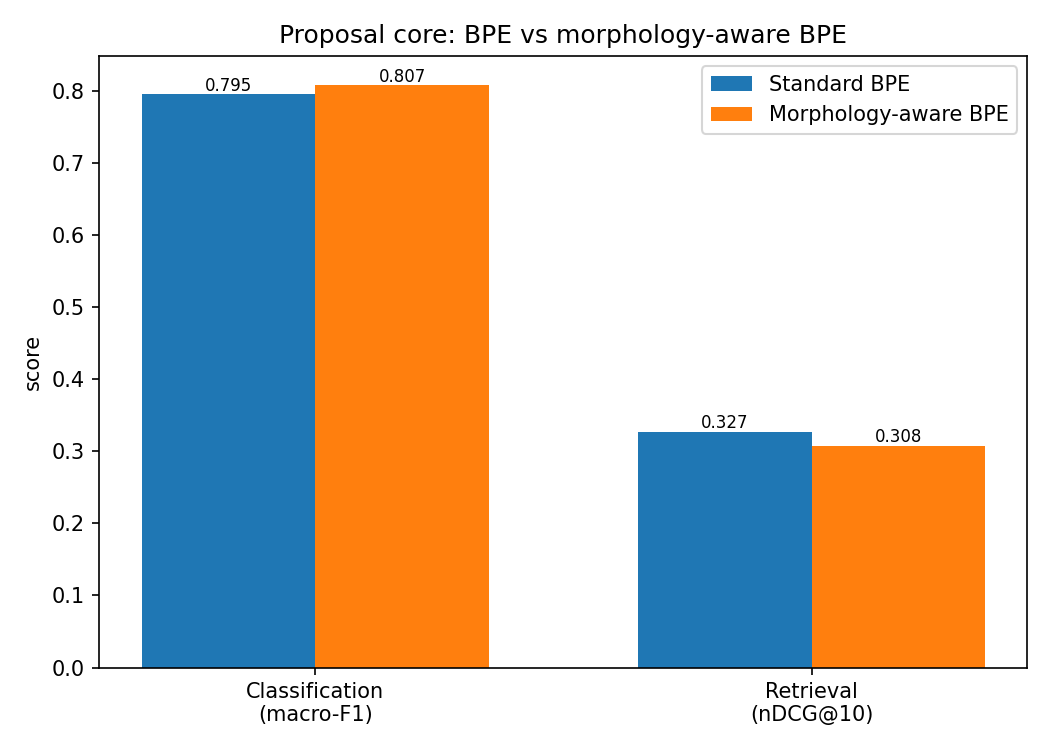

results/figures/token_histogram.png


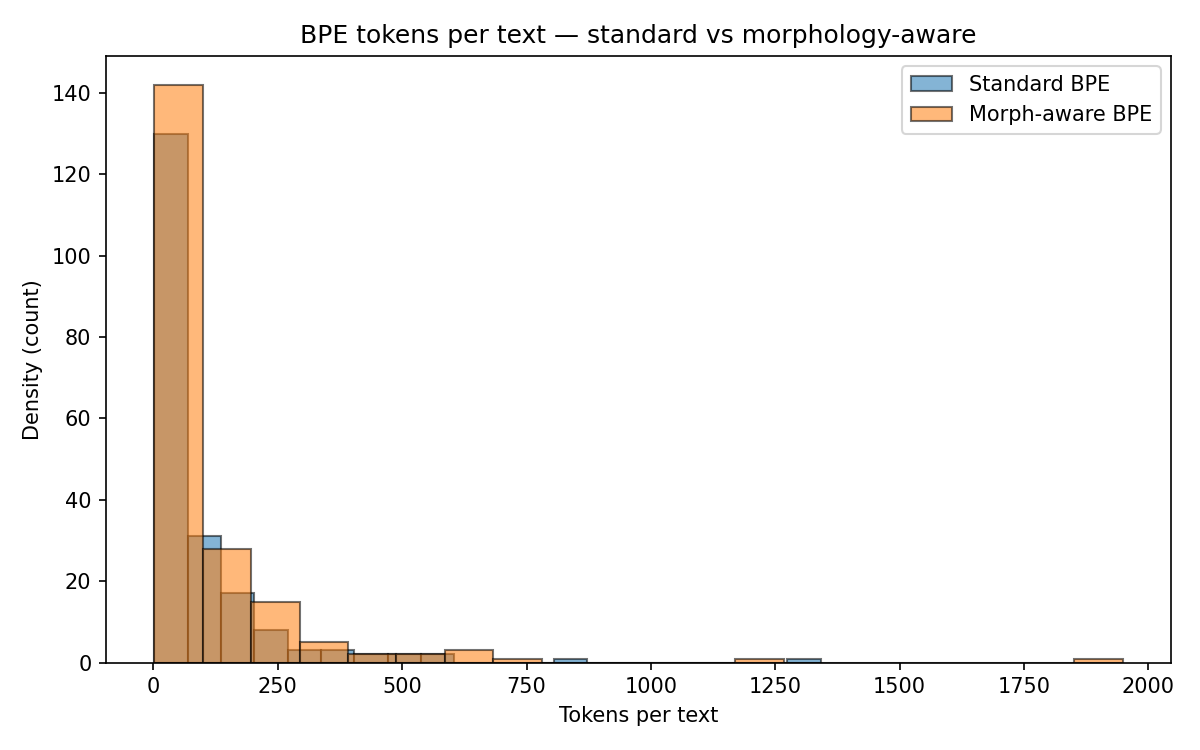

In [44]:
_pngs = sorted(glob.glob('results/figures/*.png'))
if not _pngs:
    print('No figure files produced yet — run Section 5 first.')
for _img in _pngs:
    print(_img)
    display(Image(_img))


## 9. Download results


In [45]:
!zip -rq results.zip results/ trained_tokenizers/
from google.colab import files
files.download('results.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [46]:
import shutil
from pathlib import Path
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_dir = Path(f"/content/drive/MyDrive/Arabic_Morph_NLP_Project_Backup_{timestamp}")
backup_dir.mkdir(parents=True, exist_ok=True)

items_to_save = [
    "results",
    "trained_tokenizers",
    "src",
    "config.py",
    "check_segmentation.py",
    "run_analysis.py",
    "run_bpe_tasks.py",
    "run_vocab_sensitivity.py",
    "compile_results.py",
]

for item in items_to_save:
    src = Path(item)
    if src.exists():
        dst = backup_dir / src.name
        if src.is_dir():
            shutil.copytree(src, dst, dirs_exist_ok=True)
        else:
            shutil.copy2(src, dst)
        print(f"Saved: {item}")
    else:
        print(f"Missing, skipped: {item}")

print("\nBackup saved successfully to:")
print(backup_dir)

Saved: results
Saved: trained_tokenizers
Saved: src
Saved: config.py
Saved: check_segmentation.py
Saved: run_analysis.py
Saved: run_bpe_tasks.py
Saved: run_vocab_sensitivity.py
Saved: compile_results.py

Backup saved successfully to:
/content/drive/MyDrive/Arabic_Morph_NLP_Project_Backup_20260614_114331


In [47]:
import shutil
from pathlib import Path

package_dir = Path("Arabic_Morph_NLP_Final_Package")
package_dir.mkdir(exist_ok=True)

items = [
    "results",
    "trained_tokenizers",
    "src",
    "config.py",
    "check_segmentation.py",
    "run_analysis.py",
    "run_bpe_tasks.py",
    "run_vocab_sensitivity.py",
    "compile_results.py",
]

for item in items:
    p = Path(item)
    if p.exists():
        target = package_dir / p.name
        if p.is_dir():
            shutil.copytree(p, target, dirs_exist_ok=True)
        else:
            shutil.copy2(p, target)

shutil.make_archive("Arabic_Morph_NLP_Final_Package", "zip", package_dir)
print("Created: Arabic_Morph_NLP_Final_Package.zip")

Created: Arabic_Morph_NLP_Final_Package.zip


In [48]:
from google.colab import files

files.download("Arabic_Morph_NLP_Final_Package.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>